# 📊 FoodHub NYC: Strategic Data Analysis & Operational Roadmap

### Problem Statement
The NYC restaurant scene is more competitive than ever, and for the thousands of students and professionals relying on FoodHub, the delivery experience is just as important as the food itself. While FoodHub acts as the vital bridge between a single app and hundreds of kitchens, the business model relies on a fine balance: keeping customers happy enough to rate and return, while maintaining efficient logistics across a city that never stops.

Currently, FoodHub has a wealth of data sitting in its portal, but raw data doesn't tell a story. We have orders coming in, drivers moving across the city, and a significant portion of customers who stay silent after their meal. The challenge is to dig into these numbers to find out what actually drives a 5-star experience. Is it just about being fast? Or is it about consistency, price-to-quality perception, and understanding the "logistical tax" of a New York weekday? Without these answers, we’re just moving boxes; with them, we can optimize the entire ecosystem.

### Objectives
As a Data Scientist on this project, my goal is to transform this dataset into a strategic roadmap for FoodHub. The focus is not just on answering surface level questions, but on uncovering the deeper trends that influence business growth:

**Behavioral Deep Dive**: Understand the "When" and "What" analyzing demand patterns across different days of the week and identifying which cuisines are the true revenue drivers.

**Operational Benchmarking**: Quantify the efficiency of the delivery lifecycle, specifically identifying whether delays are happening in the kitchen or on the road.

**Customer Sentiment Analysis**: Decode the rating system to figure out what triggers a high rating versus a "Not Given" response and, specifically, how order cost and delivery time play into customer psychology.

**Actionable Strategy**: Provide concrete, data-backed recommendations to the FoodHub team to help them improve restaurant partnerships, streamline logistics, and ultimately, scale the business effectively in a crowded market.

### Data Dictionary

- `order_id`: Unique ID of the order
- `customer_id`: ID of the customer who ordered the food
- `restaurant_name`: Name of the restaurant
- `cuisine_type`: Cuisine ordered by the customer
- `cost_of_the_order`: Cost of the order
- `day_of_the_week`: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
- `rating`: Rating given by the customer out of 5
- `food_preparation_time`: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
- `delivery_time`: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

## Section 1: Strategic Foundation & Data Audit

### 1.1 Library Imports and Configuration

- I am using **Pandas** and **NumPy** for data manipulation and handling missing values. 
- For data visualization, **Seaborn** and **Matplotlib** are utilized to explore distributions and relationships within the dataset.
- To ensure a professional and consistent aesthetic across all visualizations, I have set the plotting theme to whitegrid.
- Additionally, I have also configured the float format to two decimal places to ensure the statistical summaries remain readable and free of scientific notation.

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for all upcoming plots to look professional
sns.set_theme(style='whitegrid')

# Configuration for clean output
pd.options.display.float_format = '{:.2f}'.format

### 1.2 Data Acquisition & Initial Inspection

#### Data Loading and Inspection
The dataset is loaded using a relative path to ensure reproducibility. 

I will perform an initial preliminary inspection of the first and last five rows to verify the data structure and check for any obvious formatting issues at the boundaries of the file.

In [2]:
df = pd.read_csv('foodhub_order.csv')

In [3]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [4]:
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


### 1.3 Structural Integrity & Metadata Review
Before proceeding to analysis, I am evaluating the technical structure of the data, including feature names, dimensions, and memory usage.

In [5]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

Dataset Shape: (1898, 9)
Total Duplicate Rows: 0


In [6]:
# Reviewing feature names to plan univariate and bivariate analysis
df.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

In [7]:
# Checking the shape of the dataset
df.shape

(1898, 9)

#### Observations:
The dataset contains **1,898 unique orders (rows)** and **9 descriptive features (columns)**.

The volume of data is sufficient to identify patterns in cuisine preference and delivery performance without being so large that it requires specialized big-data processing.


In [8]:
# Checking the datatypes of the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The dataset consists of **1,898 entries** and **9 columns**. The distribution of data types is as follows:

- **Object (4 columns)**: `restaurant_name`, `cuisine_type`, `day_of_the_week`, and `rating`.

- **Integer (4 columns)**: `order_id`, `customer_id`, `food_preparation_time`, and `delivery_time`.

- **Float (1 column)**: `cost_of_the_order`.

<u>**Key Findings:**</u>

- **Data Integrity**: There are no immediate null values identified by the `.info()` function, suggesting a complete dataset.

- **Data Quality Note**: Although **`rating`** is logically a numerical value, it is stored as an **`object`** type. This indicates the presence of non-numeric strings (such as 'Not given') that will require preprocessing before performing any quantitative analysis on customer satisfaction.

### 1.4 Data Type Optimization

In [9]:
# Converting Order ID and Customer ID from integers to objects (strings)
df['order_id'] = df['order_id'].astype('str')
df['customer_id'] = df['customer_id'].astype('str')

# Verifying the change in data types
print(df[['order_id', 'customer_id']].dtypes)

order_id       object
customer_id    object
dtype: object


<u>**Data Type Conversion:**</u>

*   **Logical Re-classification:** Although `order_id` and `customer_id` are stored as integers, they are **qualitative identifiers**, not quantitative measures. 
*   **Preventing Misleading Statistics:** I have converted these to `object` (string) to prevent the system from calculating meaningless statistics such as the "mean" or "sum" of ID numbers during exploratory data analysis.
*   **Data Integrity:** This ensures that these columns are treated as categorical labels, which is essential for correctly identifying unique orders and returning customers without numerical bias.

### 1.5 Data Cleaning & Handling "Hidden" Missing Values

In [10]:
# Initial check for missing values
print("Initial null count:")
print(df.isnull().sum())

print("-"*50)

# Treatment: Replacing 'Not given' with NaN and converting to float
# Note: I'm using float because NaN is a float type in Pandas
df['rating'] = df['rating'].replace('Not given', np.nan).astype(float)

# Verifying the change
print("\nNew null count in 'rating' column:", df['rating'].isnull().sum())
print("New 'rating' datatype:", df['rating'].dtype)

Initial null count:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64
--------------------------------------------------

New null count in 'rating' column: 736
New 'rating' datatype: float64


#### Observations:

- **Standard Missing Value Check**: The initial `.isnull().sum()` check returned **0 null values**, indicating no technically empty cells.

- **Identification of Hidden Missing Values**: Upon inspection, the **`rating`** column was found to contain the string **'Not given'**, which serves as a placeholder for missing data.

- <u>**Treatment Applied:**</u>

  - Replaced all **'Not given'** entries with `np.nan` to correctly represent them as missing numerical data.

  - Converted the `rating` column data type from `object` to `float`.

  - **Note**: I chose `float` instead of `int` because `NaN` values are mathematically treated as floats in Python, allowing for accurate calculation of the mean and median later.

### 1.6 Statistical Profiling

In [11]:
# Displaying the statistical summary (Transposed for better readability)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


#### Observations:

Based on the statistical summary of the dataset:

*   **Food Preparation Time:**
    *   **Minimum Time:** 20.00 minutes
    *   **Maximum Time:** 35.00 minutes
    *   **Average (Mean) Time:** 27.37 minutes

*   **Distribution Analysis:**
    The **Mean (27.37)** and **Median (27.00)** are nearly identical, which strongly suggests that the food preparation time follows a **normal distribution** with no significant skewness.

*   **Cost of Order:**
    The average cost per order is approximately **\$16.50**, with a wide range between **\$4.47** and **\$35.41**, indicating a diverse price point for the meals offered.

*   **Customer Ratings:**
    Now that the `rating` column has been converted to numerical values, we can see the average rating is approximately **4.34**, suggesting a high level of customer satisfaction for the rated orders.

In [12]:
# Counting the missing values in the rating column
df['rating'].isnull().sum()

np.int64(736)

#### Observations:
**Missing Value Count**: Out of the **1,898** total records, there are **736 null values** in the `rating` column.

**Data Proportion**: This signifies that approximately **38.78%** of the orders are unrated.

**Analytical Impact**: Having nearly **40%** of the `rating` data missing presents a significant challenge for analysis.

**Imputation Risk**: Standard imputation methods (like filling with the mean or median) could introduce substantial bias, as we only have **61.22%** of actual customer feedback to work with.

**Strategy**: For the purpose of this analysis, we will work with the available data while acknowledging that conclusions regarding customer satisfaction are based on a partial sample of the total orders.

## Section 2: Univariate Analysis - The Pulse of FoodHub

### <u>**Univariate Analysis Strategy**</u>

Before proceeding with the visualizations, I am categorizing the variables to determine the most effective way to extract insights from each. 

#### **1. Variables to be Excluded**
*   **Order ID & Customer ID:** These have been converted to `object` types. They are unique identifiers used for tracking and do not possess meaningful numerical properties (e.g., calculating the average 'Order ID' provides no value). These will be excluded from distribution plots.

#### **2. Categorical Variables**
For these variables, we will use **Countplots** to identify frequency and popularity:
*   **Restaurant Name:** To identify the "Market Leaders" and the extent of the "Long Tail" (variety vs. popularity).
*   **Cuisine Type:** To understand the most preferred food categories on the platform.
*   **Day of the Week:** To compare order volumes between Weekdays and Weekends for operational insights.

#### **3. Numerical Variables**
For our Univariate Analysis, we will choose the visualization based on the nature of the data:

*   **Numerical Continuous Variables (Combo Plots):** For these, we will use a combination of **Histograms (with KDE)** and **Boxplots**. This allows us to see central tendency, spread, and identify potential outliers:
    *   **Cost of Order:** To check for price distribution and identify if the data is skewed.
    *   **Food Preparation Time:** To understand the efficiency of the kitchens.
    *   **Delivery Time:** To evaluate the logistics and speed of the delivery network.
    *   **Total Order Time (Calculated):** A derived variable ($Food\ Prep\ Time + Delivery\ Time$) representing the full end-to-end customer wait time. This is a critical KPI for customer satisfaction.

*   **Numerical Discrete/Ordinal Variables (Countplots):** 
    *   **Rating:** To assess customer satisfaction. Since ratings are discrete (3, 4, 5) rather than continuous, a **Countplot** is more suited to visualize the frequency of each score (keeping in mind that ~39% of this data is missing/NaN).

---

### 2.1. Brand Dominance: Restaurant Popularity

In [13]:
# Check the total number of unique restaurants to understand the scale of the variable
df['restaurant_name'].nunique()

178

<u> Note</u>: While FoodHub partners with 178 unique restaurants, this analysis highlights the Top 20 to ensure visual clarity and actionable insights.

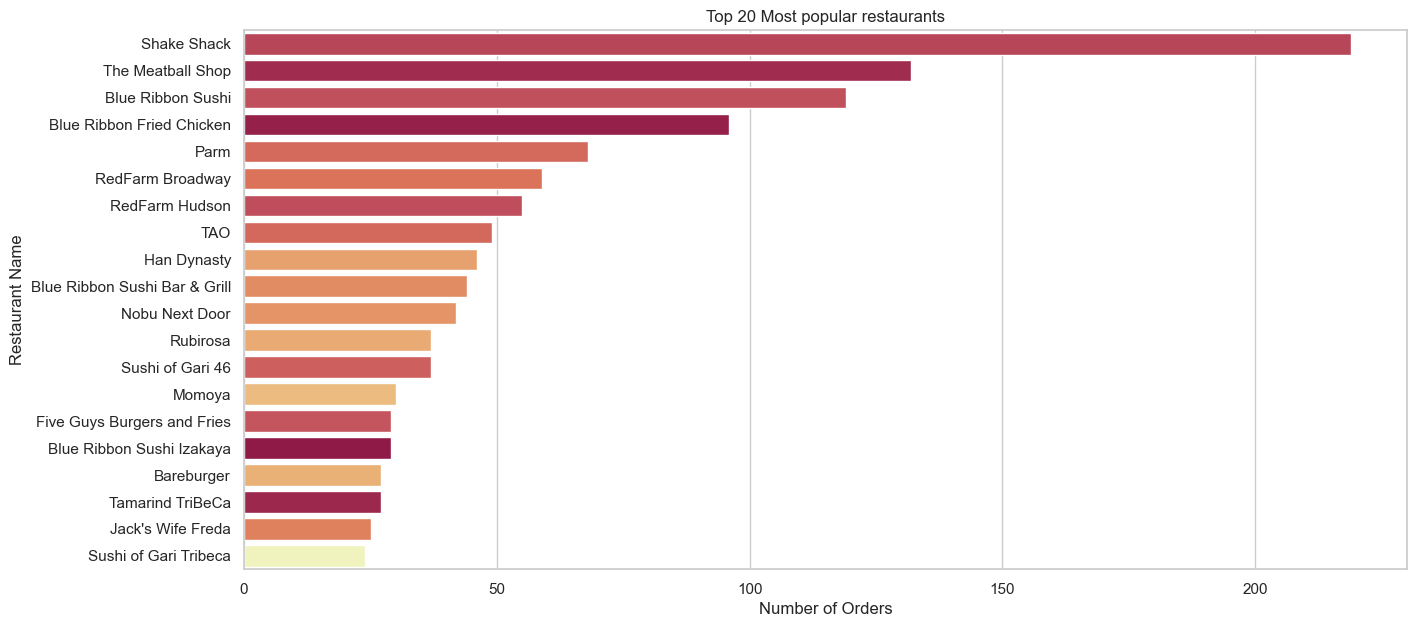

Number of restaurants with only one order: 50


In [14]:
# Set the figure size for a clear, readable horizontal bar chart
plt.figure(figsize = (15,7))

# Plotting the Top 20 restaurants using a countplot
# I'm using hue and legend=False to comply with the latest Seaborn formatting rules
sns.countplot(data = df, y = 'restaurant_name', 
              order = df['restaurant_name'].value_counts().index[:20], 
              hue = 'restaurant_name', 
              legend = False, 
              palette = 'Spectral')

# Adding descriptive labels and title
plt.title('Top 20 Most popular restaurants')
plt.ylabel('Restaurant Name')
plt.xlabel('Number of Orders')

# Displaying the plot
plt.show()

# Checking how many restaurants have only a single order in this dataset
single_order_count = (df['restaurant_name'].value_counts() == 1).sum()
print(f"Number of restaurants with only one order: {single_order_count}")

#### **Observations: Restaurant Popularity**

*   **Market Dominance:** Out of **178 unique restaurants**, a small group dominates the platform. The top brands (e.g., Shake Shack, The Meatball Shop) have significantly higher order volumes, suggesting high brand loyalty or successful marketing on the app.
*   **The "Long Tail" Effect:** While there are nearly 1,900 orders, the analysis reveals a significant "long tail" in the distribution. 
    *   Specifically, **50 restaurants** (out of 178) have only a single order in this dataset.
    *   This indicates that while the platform offers great variety, the majority of the revenue is driven by a few "powerhouse" partners.
*   **Business Insight:** Identifying these "anchor brands" is crucial for the aggregator’s retention strategy. Conversely, the high number of single-order restaurants might suggest an opportunity to investigate why those partners aren't seeing repeat business (e.g., poor ratings, limited menu, or high delivery times).

### 2.2. Culinary Trends: Cuisine Type Distribution

In [15]:
# Check the total number of unique cuisines to understand the scale of the variable
df['cuisine_type'].nunique()

14

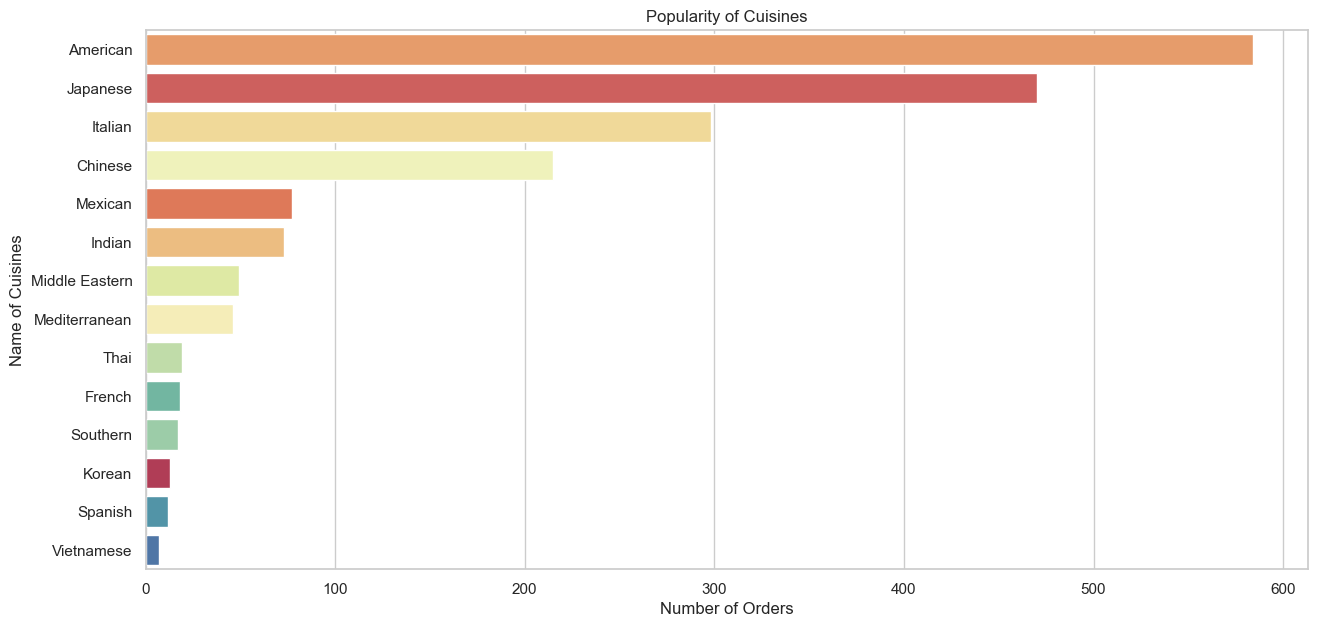

In [16]:
# Setting the visual scale of the plot
plt.figure(figsize = (15,7))

# Using a countplot for categorical analysis of cuisine types
# .index ensures the bars are sorted from the highest to lowest frequency
sns.countplot(
    data = df, 
    y = 'cuisine_type', 
    order = df['cuisine_type'].value_counts().index, 
    hue = 'cuisine_type', # Mapping y to hue to satisfy latest Seaborn requirements
    legend = False,       # Removing the legend as the Y-axis already provides the labels
    palette = 'Spectral'  # Using a diverse color palette for visual distinction
)

# Adding descriptive titles and axis labels for clarity
plt.title('Popularity of Cuisines')
plt.ylabel('Name of Cuisines')
plt.xlabel('Number of Orders')

# Displaying the plot
plt.show()

#### **Observations: Cuisine Type Popularity**

*   **Dominant Cuisines:** The distribution is heavily dominated by four major cuisine types: **American, Japanese, Italian, and Chinese**. 
    *   **American Cuisine** is the single most popular, which aligns with our previous finding that 'Shake Shack' is a top performing restaurant.
*   **The "Big Four" Share:** These top four categories represent the vast majority of orders on the platform, suggesting that the customer base has a strong preference for mainstream "fast-casual" and international staples.
*   **Niche/Underrepresented Categories:** Cuisines like **Thai, French, Southern, Korean, Spanish, and Vietnamese** are at the lowest end of the spectrum.
    *   *Insight:* This could indicate either a lack of supply (not enough of these restaurants on the app) or a lower demand for these specific niches in the current market.
*   **Business Opportunity:** For FoodHub, there is a clear opportunity to either double down on the "Big Four" or attempt to diversify the platform by onboarding more high quality niche restaurants (like Korean or Thai) to attract a broader demographic.

### 2.3. Temporal Patterns: Weekday vs. Weekend Volume

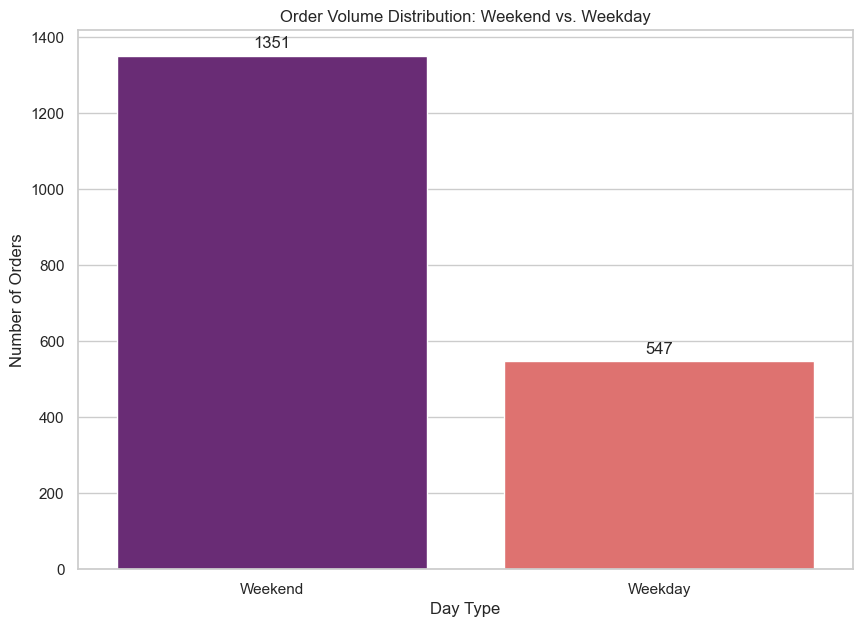

In [17]:
# Setting the visual scale of the plot
plt.figure(figsize = (10, 7))

# Using a countplot to compare volume across the two day-types
# Using a vertical plot (x=) clearly shows the 'height' of demand
ax = sns.countplot(
    data = df, 
    x = 'day_of_the_week', 
    hue = 'day_of_the_week', 
    legend = False,       
    palette = 'magma' # A different palette to distinguish from previous sections
)

# Writing a loop to iterate through the bars and add the text labels of order counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

# Adding descriptive titles and labels
plt.title('Order Volume Distribution: Weekend vs. Weekday')
plt.ylabel('Number of Orders')
plt.xlabel('Day Type')

# Displaying the plot
plt.show()

#### **Observations: Order Volume (Weekend vs Weekday)**

- **Significant Weekend Surge**: Total order volume during the Weekend (**1,351 orders**) is **2.47 times** higher than the total Weekday volume (**547 orders**).

- **Operational Intensity & Density**: While the "Weekend" consists of only two days, it accounts for approximately **71.2%** of the total orders in this dataset.

  - **Weekday Density**: ~109 orders per day.

  - **Weekend Density**: ~675 orders per day.

  - _Insight_: The platform is roughly **6 times busier** on a Saturday or Sunday than on a typical weekday, creating a massive operational "spike."

- **Strategic Implication**: This suggests that the platform’s revenue is heavily "**weekend-loaded**." Operationally, FoodHub must prioritize **driver availability** and **app server stability** during these peak 48 hours to prevent delivery delays or system crashes during high-concurrency periods.

- **Growth Opportunity**: There is a clear "mid-week slump." To optimize revenue during the Monday-Friday period, the business could explore:

  - "**Weekday-only**" promotional codes.

  - Targeting corporate "Work From Home" lunch specials to boost volume during off-peak days.

### 2.4. Pricing Architecture: Cost of Orders

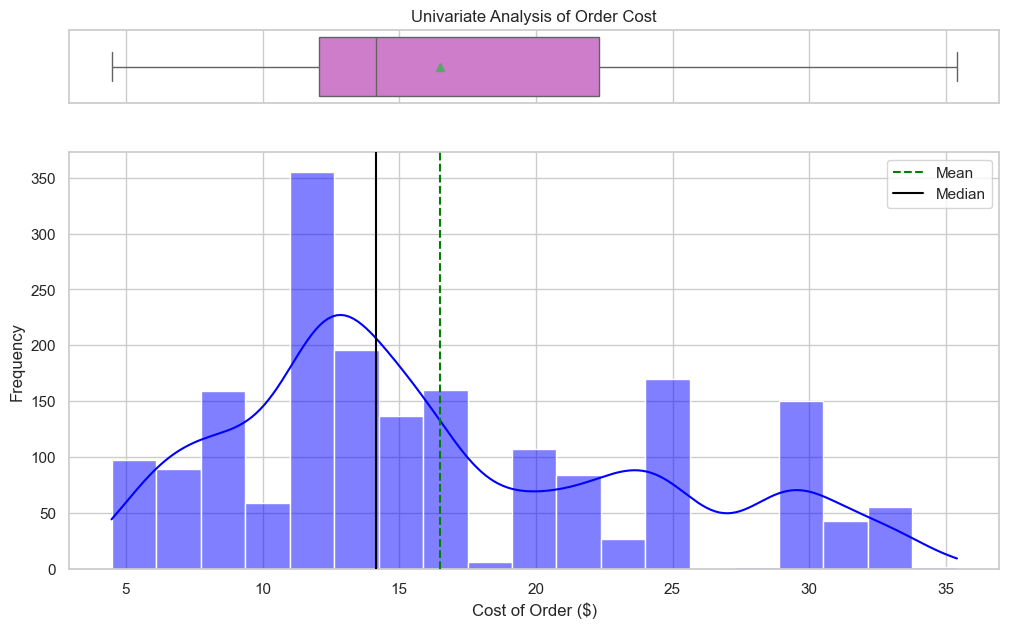

In [18]:
# Creating a figure with two subplots: a Boxplot and a Histogram
# sharex=True ensures both plots use the exact same scale for the Cost ($)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                    gridspec_kw={"height_ratios": (.15, .85)}, 
                                    figsize=(12, 7))

# Plot 1: Boxplot on top (ax_box)
sns.boxplot(data=df, x='cost_of_the_order', ax=ax_box, color='orchid', showmeans=True)

# Plot 2: Histogram with KDE on bottom (ax_hist)
sns.histplot(data=df, x='cost_of_the_order', kde=True, ax=ax_hist, color='blue')

# Customizing the labels and titles for professional presentation
ax_box.set(title='Univariate Analysis of Order Cost', xlabel='')
ax_hist.set(xlabel='Cost of Order ($)', ylabel='Frequency')

# Adding a vertical line for the mean on the histogram to visualize skewness
plt.axvline(df['cost_of_the_order'].mean(), color='green', linestyle='--', label='Mean', zorder = 3)
plt.axvline(df['cost_of_the_order'].median(), color='black', linestyle='-', label='Median', zorder = 3)
plt.legend()

plt.show()

#### **Observations: Cost of Order**
*   **Central Tendency:** The **mean order cost (\$16.48)** is higher than the **median (\$14.14)**.
    
*   **Right Skewness:** Because the mean is pulled toward the higher values and the right "whisker" of the boxplot is longer than the left, the distribution is **Right Skewed** (Positively Skewed). This indicates that while many orders are budget-friendly, a significant number of higher-priced orders are pulling the average up.
    
*   **Multimodal Distribution:** The Histogram and KDE curve reveal that this isn't a simple "bell curve." It is **multimodal**, featuring distinct peaks of popularity:
    *   **Primary Peak (`$11`–`$13`):** The "sweet spot" where the highest volume of orders occurs.
    *   **Secondary Peaks (`~$25` and `~$30`):** Smaller "humps" likely representing group orders or premium-tier dining segments.

*   **Outlier Analysis:** The boxplot shows **no outliers**. Even the maximum order value (approx. \$35) falls within the statistical "normal range." This suggests the current price ceiling is well-integrated into the platform's ecosystem and is not driven by extreme, one-off anomalies.
  
*   **Market Diversity (IQR):** The **Interquartile Range (IQR)** is notably wide, spanning roughly from **`$12` to `$22`**. This high variance indicates that FoodHub is a **highly diverse marketplace** successfully catering to both value-seekers and premium spenders.
  
*   **Business Insight:** The presence of the **`$25` and `$30` peaks** suggests a healthy "premium" segment. During bivariate analysis, we should investigate if these high-value orders are linked to specific cuisines or weekend-specific consumer behaviors.

### 2.5. Operational Efficiency: Food Preparation Time

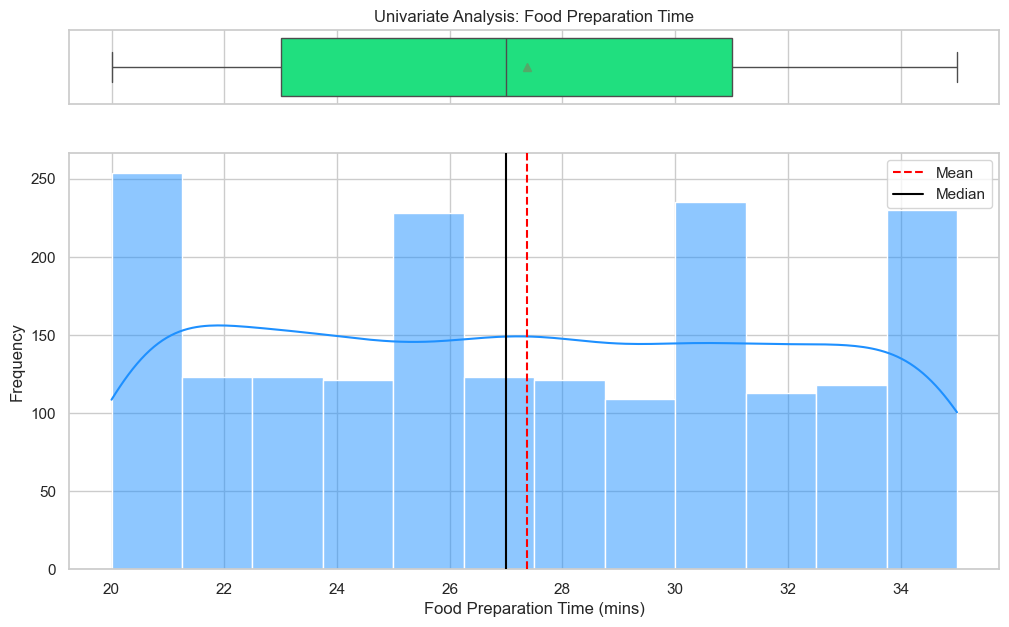

In [19]:
# Creating a figure with two subplots: a Boxplot and a Histogram
# sharex=True ensures both plots use the exact same scale for the Cost ($)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                    gridspec_kw={"height_ratios": (.15, .85)}, 
                                    figsize=(12, 7))

# Plot 1: Boxplot on top (ax_box)
sns.boxplot(data=df, x='food_preparation_time', ax=ax_box, color='springgreen', showmeans=True)

# Plot 2: Histogram with KDE on bottom (ax_hist)
sns.histplot(data=df, x='food_preparation_time', kde=True, ax=ax_hist, color='dodgerblue')

# Customizing the labels and titles for professional presentation
ax_box.set(title='Univariate Analysis: Food Preparation Time', xlabel='')
ax_hist.set(xlabel='Food Preparation Time (mins)', ylabel='Frequency')

# Adding a vertical line for the mean on the histogram to visualize skewness
plt.axvline(df['food_preparation_time'].mean(), color='red', linestyle='--', label='Mean', zorder = 3)
plt.axvline(df['food_preparation_time'].median(), color='black', linestyle='-', label='Median', zorder = 3)
plt.legend()

plt.show()

#### **Observations: Food Preparation Time**
*   **Central Tendency:** The **mean (27.37 minutes)** and **median (27.0 minutes)** are nearly identical, indicating a highly symmetrical distribution with no significant skewness.

*   **Nature of Distribution (Uniformity):** While the histogram shows slight peaks at specific intervals (e.g., 20–21, 25–26, 30–31, and 34–35 minutes), the **KDE curve remains relatively flat**. This indicates a **Uniform Distribution** rather than a Normal one.
    *   *Insight:* Any time within the 20–35 minute range is almost equally likely. There is no clear "standard" preparation time, suggesting high variability in restaurant operations.

*   **Symmetry and Spread:** The whiskers of the boxplot are almost identical in length, and the box itself is centered. This confirms that the data is balanced and consistent across its entire range (20 to 35 minutes).

*   **Outlier Analysis:** There are **no outliers** present. All recorded preparation times fall within the expected operational window.

*   **Operational Range & System Constraints:** The data is strictly bounded between **20 and 35 minutes**. The sharp "cutoff" points suggest potential system-level constraints; for instance, the platform may not record preparation times below 20 minutes or may automatically cap the prep phase at 35 minutes.

*   **Reliability:** Because the range is so tight (only a 15-minute window) and lacks outliers, FoodHub can reliably inform customers that their food will *almost always* be ready within this specific window.

*   **Operational Takeaway:** Since preparation time is spread so evenly across this window, FoodHub cannot easily "predict" an average wait time based on preparation alone. Logistics planning must account for this consistent variability.

### 2.6. Logistical Throughput: Delivery Time

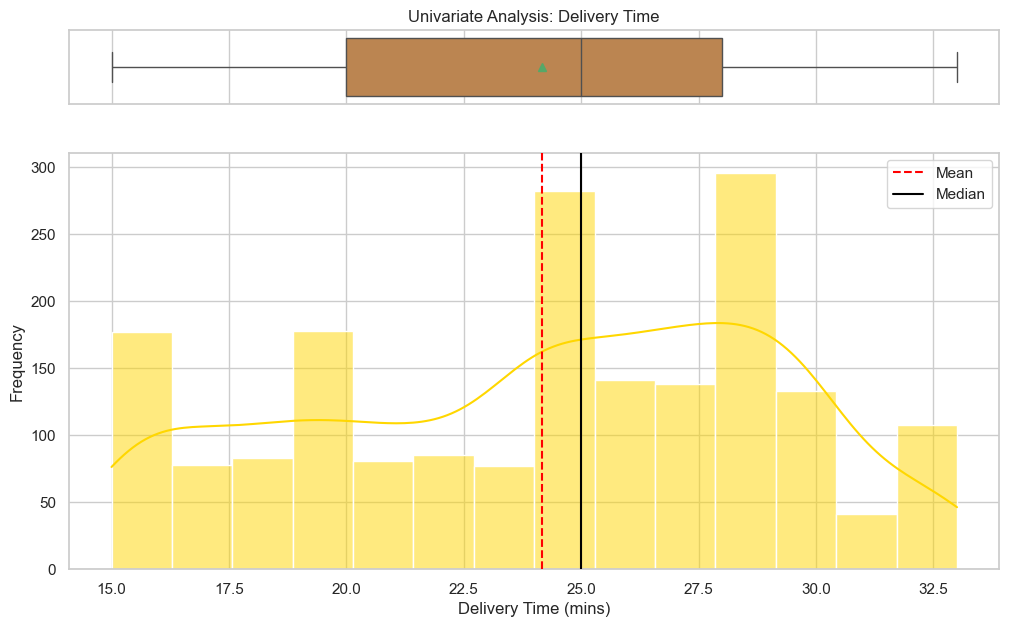

In [20]:
# Creating a figure with two subplots: a Boxplot and a Histogram
# sharex=True ensures both plots use the exact same scale for the Cost ($)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                    gridspec_kw={"height_ratios": (.15, .85)}, 
                                    figsize=(12, 7))
# Plot 1: Boxplot on top (ax_box)
sns.boxplot(data=df, x='delivery_time', ax=ax_box, color='peru', showmeans=True)

# Plot 2: Histogram with KDE on bottom (ax_hist)
sns.histplot(data=df, x='delivery_time', kde=True, ax=ax_hist, color='gold')


# Customizing the labels and titles for professional presentation
ax_box.set(title='Univariate Analysis: Delivery Time', xlabel='')
ax_hist.set(xlabel='Delivery Time (mins)', ylabel='Frequency')

# Adding a vertical line for the mean on the histogram to visualize skewness
plt.axvline(df['delivery_time'].mean(), color='red', linestyle='--', label='Mean', zorder = 3)
plt.axvline(df['delivery_time'].median(), color='black', linestyle='-', label='Median', zorder = 3)
plt.legend()

plt.show()

#### **Observations: Delivery Time**
*   **Central Tendency & Skewness:** The **mean (24.16 minutes)** is slightly lower than the **median (25.0 minutes)**, which indicates a **slight left skew (negative skew)**.
  
    *   *Interpretation:* The average delivery is faster than the middle value, likely driven by a high volume of efficient, shorter-distance trips that pull the mean toward the lower end.

*   **Distribution Shape:** The KDE curve reveals two subtle modal regions (peaks) around **25 and 28 minutes**. 
    *   *Insight:* This suggests that most deliveries cluster in this 3-minute window, though the overall distribution is relatively spread out across the range.

*   **Symmetry and Spread:** The whiskers of the boxplot are nearly equal in length, suggesting that while the data is slightly skewed, the overall variability is consistent. Most deliveries are completed between approximately **15 and 33 minutes**.

*   **The "Last Mile" Baseline:** The data shows a "floor" of roughly **15 minutes** for delivery. 
    *   *Operational Takeaway:* Unlike the 20-minute minimum for food preparation, the 15-minute delivery minimum represents the physical time required for transit, parking, and order hand-off, even for the closest customers.

*   **Outlier Analysis:** There are **no outliers** present in the delivery data. This indicates that extreme delays (due to unusual traffic or accidents) are either rare or were not captured in this specific subset of data.

*   **Comparison to Prep Time:** Delivery time shows more natural "real-world" variation than the preparation time. While preparation was a "controlled plateau" (Uniform), delivery time behaves more like a slightly skewed distribution influenced by external logistics.

### 2.7. The End-to-End Experience: Total Time (Derived KPI)

In [21]:
# Creating the 'total_time' column as the sum of prep and delivery
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Quick check of the new column's basic stats
print(df['total_time'].describe())

count   1898.00
mean      51.53
std        6.83
min       35.00
25%       47.00
50%       52.00
75%       56.00
max       68.00
Name: total_time, dtype: float64


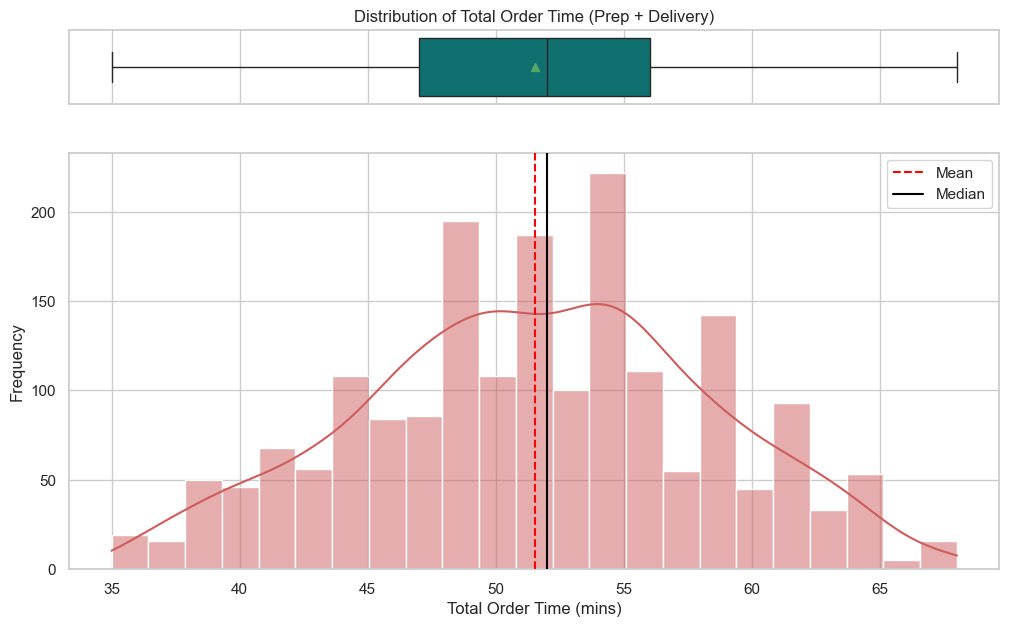

In [22]:
# Creating a figure with two subplots: a Boxplot and a Histogram
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                    gridspec_kw={"height_ratios": (.15, .85)}, 
                                    figsize=(12, 7))

# Plot 1: Boxplot on top (ax_box)
sns.boxplot(data=df, x='total_time', ax=ax_box, color='teal', showmeans = True)

# Plot 2: Histogram with KDE on bottom (ax_hist)
sns.histplot(data=df, x='total_time', kde=True, ax=ax_hist, color='indianred')

# Customizing the labels and titles for professional presentation
ax_box.set(title='Distribution of Total Order Time (Prep + Delivery)', xlabel = '')
ax_hist.set(xlabel='Total Order Time (mins)', ylabel='Frequency')

# Adding a vertical line for the mean on the histogram to visualize skewness
plt.axvline(df['total_time'].mean(), color='red', linestyle='--', label='Mean', zorder = 3)
plt.axvline(df['total_time'].median(), color='black', linestyle='-', label='Median', zorder = 3)
plt.legend()

plt.show()

#### **Observations: Total Order Time (End-to-End Customer Experience)**

*   **Primary Performance Metric:** From the perspective of the end consumer, Total Order Time (Prep + Delivery) is the most critical KPI. It represents the actual wait time and directly impacts customer satisfaction and ratings.
*   **Central Tendency:** The **mean (51.53 mins)** and **median (52 mins)** are nearly identical, indicating a symmetrical distribution. This suggests that the "typical" customer experience is a wait of nearly an hour, regardless of the restaurant or cuisine.
*   **The "Hour" Threshold:** With the median at 52 minutes, over half of all customers are waiting nearly an hour for their food. In a competitive market, crossing the 50-60 minute mark is a major friction point that likely risks negative reviews and lower retention.
*   **Bimodal Distribution:** The KDE plot reveals two significant peaks (around **49-50 mins** and **55 mins**). This suggests two common service scenarios, possibly driven by differences in weekday traffic vs. weekend peaks or varying preparation complexities.
*   **The "Physical Minimum" Insight:** 
    *   The minimum total time recorded is **35 minutes**. 
    *   *Analysis:* This perfectly aligns with our individual metrics (Min Prep Time of 20 mins + Min Delivery Time of 15 mins). This reveals an "operational floor" under current conditions, it is physically impossible for a customer to receive food in less than 35 minutes, regardless of how close they live to the restaurant.
*   **The "Long Tail" Risk:** At the upper bound, it takes a maximum of **68 minutes** to get food to the customer. These orders are the "danger zone" for the brand, as wait times exceeding an hour are the surest way to elicit "angry reactions from hungry customers." These orders are high-risk for customer churn.
*   **Operational Conclusion:** While the consistency (low skewness) is good for predictability, the baseline wait is high. Strategic focus should be on reducing the "Prep + Delivery" overlap to push the mean closer to the 40-45 minute range in a competitive market.

### 2.8. Satisfaction Metrics: Rating Distribution

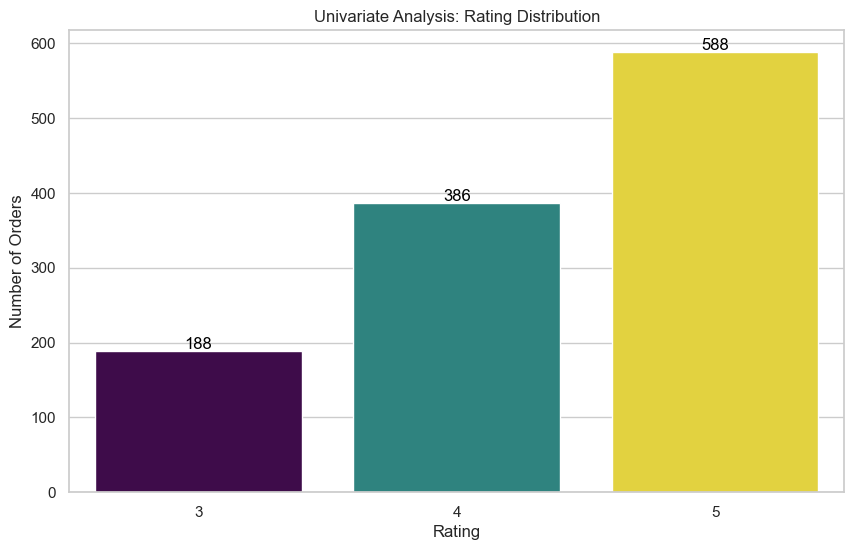

In [23]:
# Setting the visual scale of the plot
plt.figure(figsize=(10, 6))

# Using a countplot because Rating is categorical/ordinal
ax = sns.countplot(data=df, 
                   x='rating', 
                   hue = 'rating', 
                   legend = False, 
                   palette='viridis')

# Forcing the X-axis to show specific integer labels
plt.xticks([0, 1, 2], ['3', '4', '5'])

plt.title('Univariate Analysis: Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')

# Adding the actual counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
   
plt.show()

#### **Observations: Rating**
*   **Distribution Sentiment:** The distribution is heavily skewed toward high satisfaction, with **5-star ratings (588)** being the most frequent, followed by 4s (386) and 3s (188).

*   **Missing Data (Selection Bias):** Only **~61.2% of orders (1,162 out of 1,898)** have an associated rating. This indicates a significant "non-response bias," where nearly 40% of customers are a "silent majority."

*   **Absence of Low Ratings:** There are **zero 1-star or 2-star ratings** in the dataset. While this could suggest high service quality, in a real-world scenario, it often points to data filtering or a platform culture where only positive experiences are recorded.

*   **Business Opportunity:** The large volume of unrated orders represents a "feedback gap." FoodHub is missing critical data on the average customer experience.

*   **Operational Recommendation:** To improve data representativeness, FoodHub should implement incentives (e.g., small discount coupons) or a simplified "one-tap" rating interface to encourage the ~39% of silent customers to provide feedback.

## Section 3: Key Performance Indicators (KPIs) & Target Metrics

### 3.1 Market Leaders: Top 5 Restaurants by Order Volume

In [24]:
top_five = df['restaurant_name'].value_counts().head(5)
print(top_five)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### **Observations: Top 5 Restaurants by Order Volume**
*   **Dominant Market Leader:** **Shake Shack** is the clear leader with **219 orders**, comfortably outpacing the second-place contender by a margin of 87 orders. This indicates massive brand dominance and a highly successful partnership with the FoodHub platform.
*   **The "Blue Ribbon" Brand Power:** Two of the top five spots belong to the "Blue Ribbon" brand (**Blue Ribbon Sushi** and **Blue Ribbon Fried Chicken**). 
    *   *Insight:* When combined, the Blue Ribbon brand accounts for **215 orders**, showing that their total footprint almost rivals Shake Shack's volume.
*   **Internal Brand Preference:** Within the Blue Ribbon portfolio, **Sushi (119)** is notably more popular for delivery than **Fried Chicken (96)**. This suggests customers might prefer specialized or "lighter" cuisines for transit over standard comfort food.
*   **Tight Middle-Market Competition:** There is a very close race between **The Meatball Shop (132)** and **Blue Ribbon Sushi (119)** for the second and third spots, with only a small 13-order difference.
*   **Revenue Concentration Risk:** These top 5 restaurants account for a massive chunk of total order volume (**33.4%**). From a business strategy perspective, FoodHub is heavily reliant on these "anchor" restaurants; losing even one could significantly impact platform revenue.
*   **Cuisine Indicators:** The top 5 list is dominated by **American, Italian, and Japanese** cuisines, providing a clear roadmap for where FoodHub should focus its marketing and merchant acquisition efforts.

### 3.2 Weekend Demand: The Most Popular Cuisine

In [25]:
# Filtering the dataframe for weekend orders only
weekend_df = df[df['day_of_the_week'] == 'Weekend']

# Get the value counts for cuisines during the weekend
top_cuisine_weekend = weekend_df['cuisine_type'].value_counts()

print(top_cuisine_weekend)

cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Mediterranean      32
Middle Eastern     32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64


#### **Observations: Most Popular Cuisine on Weekends**
*   **The Weekend Favorite:** **American cuisine** is the undisputed leader on weekends with **415 orders**. This suggests that customers lean heavily toward "comfort foods" like burgers, fries, and shakes during their leisure time.
*   **Top 3 Dominance:** **American, Japanese (335), and Italian (207)** represent the "Big Three" of weekend deliveries. These three categories alone account for the vast majority of FoodHub's weekend revenue.
*   **High Engagement for Japanese Cuisine:** Japanese food (specifically sushi, as noted in our restaurant analysis) remains a very strong second. This indicates that customers view Japanese cuisine as a premium "weekend treat" or a high-quality meal option for social settings.
*   **The "Mainstream" Preference:** The combined volume of American, Japanese, and Italian food far outweighs the other 11 cuisine types combined. This shows a very concentrated market preference for mainstream international cuisines.
*   **Market Opportunity:** Cuisines like **Thai, French, Spanish, Korean, Vietnamese etc** have extremely low order volumes (15 or below each). This highlights a potential growth area; FoodHub could diversify its weekend appeal by onboarding more vendors in these niche categories to attract "adventurous" eaters.

### 3.3 Revenue Tiering: High-Value Order Analysis (>$20)

In [26]:
# Filter for orders greater than 20 dollars
cost_above_20 = df[df['cost_of_the_order'] > 20]

# Calculate the percentage
# len() gives us the number of rows
percentage = (len(cost_above_20) / len(df)) * 100

print(f"Percentage of orders costing more than $20: {round(percentage, 2)}%")

Percentage of orders costing more than $20: 29.24%


#### **Observations: Order Cost Analysis (>\$20)**
*   **The "Premium" Segment:** Approximately **29.24%** of all orders (555 out of 1,898) cost more than \$20. This indicates that while the majority of orders are lower-priced, nearly a third of FoodHub's business comes from higher-value transactions.
*   **Pricing Sweet Spot:** Since ~70% of orders fall below the \$20 mark, it is clear that the platform's "sweet spot" is in the budget-to-mid-range category.
*   **Revenue Opportunity:** The ~30% of customers willing to spend over \$20 are highly valuable. FoodHub could target this segment with "Premium" membership perks or bundles to increase the average order value (AOV).
*   **Delivery Logistics:** Higher-priced orders often mean more items per bag. This data point is useful for logistics planning to ensure that "larger" orders are prioritized for cars or larger delivery bags.

### 3.4 Logistical Benchmark: Mean Order Delivery Time

In [27]:
# Calculating mean delivery time across all orders
mean_delivery_time = df['delivery_time'].mean()

# Output the result rounded to two decimal places for clarity
print(round(mean_delivery_time, 2))

24.16


#### **Observations: Average Delivery Time**
*   **Logistical Benchmark:** On average, it takes **24.16 minutes** for a driver to deliver an order once it leaves the restaurant. This represents nearly 50% of the total customer wait time.
*   **The "50/50" Split (Bottleneck Identification):** It is significant that delivery time (24.16 mins) and preparation time (approx. 27 mins) are nearly equal. On most optimized delivery platforms, transit is typically much faster than cooking. The fact that they are balanced here suggests that **transit/logistics is the primary bottleneck**, rather than kitchen efficiency.
*   **Variable Factors:** This metric is highly susceptible to external variables such as traffic congestion, weather conditions, and the efficiency of the delivery route.
*   **Operational Strain:** During peak periods (like weekends), high order volumes combined with a finite number of drivers often lead to "order clubbing" (stacking multiple deliveries). While efficient for the platform, this practice can lead to a "last-in-line" delay for certain customers, pushing the delivery time toward the higher end of the spectrum.
*   **Geographic Radius:** The ~24 minute average suggests that FoodHub’s delivery radius is likely quite broad, or that "last mile" logistics in this specific urban area are hindered by significant transit bottlenecks.
*   **Strategic Opportunity:** Since the kitchens are already performing at a similar speed to the deliveries, the most effective way to reduce the "Total Order Time" (and increase customer satisfaction) would be to optimize delivery routes or increase driver density in high traffic zones.

### 3.5 Customer Loyalty: Identifying High-Frequency Users

In [28]:
# Identifying top 3 customers
top_three_customers = df['customer_id'].value_counts().head(3)

print("Top 3 most frequent customers:")
print(top_three_customers)

Top 3 most frequent customers:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


In [29]:
# Calculating the number of unique customers to check for repeat business
unique_customers = df['customer_id'].nunique()
total_orders = len(df)
repeat_rate = (total_orders - unique_customers) / total_orders
avg_orders_per_cust = total_orders / unique_customers

print(f"Total Orders: {total_orders}")
print(f"Unique Customers: {unique_customers}")
print(f"Repeat Rate (Proxy): {round(repeat_rate * 100, 2)}%")
print(f"Average Orders per Customer: {round(avg_orders_per_cust, 2)}")

Total Orders: 1898
Unique Customers: 1200
Repeat Rate (Proxy): 36.78%
Average Orders per Customer: 1.58


#### **Observations: Analysis of Customer Loyalty and Retention**

#### **1. Identification of Power Users**
*   **Top Frequent Customers:** Customer IDs **52832 (13 orders)**, **47440 (10 orders)**, and **83287 (9 orders)** are the highest-frequency users on the platform.
*   **Reward Strategy:** Offering 20% discount vouchers to these individuals is an effective **Retention Strategy**. High-frequency customers are typically the most sensitive to service changes; rewarding them fosters brand advocacy and ensures their **Lifetime Value (LTV)** remains high.
*   **The "Context" Limitation:** Without a specific time-window (e.g., monthly vs. yearly data), it is difficult to determine the exact "intensity" of this loyalty. However, in a dataset of 1,898 orders, these users represent a distinct "heavy-user" segment compared to the majority of the customer base.

#### **2. The "Retention Gap" Analysis**
*   **High Acquisition vs. Low Retention:** Out of 1,898 total orders, there are **1,200 unique customers**. This suggests that nearly **63%** of the dataset consists of unique individuals who may have only interacted with the platform once.
*   **Low Order Frequency:** On average, a customer only places **1.58 orders**. In the food delivery industry, where profit margins rely on high-frequency, "habitual" users, this is a clear signal that the platform is currently being used for "trial" or "emergency" meals rather than as a primary food source.
*   **The "One-and-Done" Trend:** The data indicates that while FoodHub is successful at attracting new users (Acquisition), it faces a significant challenge in converting them into repeat users (Retention).
*   **Business Risk:** Relying solely on constant new customer acquisition is expensive due to high **Customer Acquisition Costs (CAC)**. Improving the repeat rate is generally more profitable than hunting for new unique users.

#### **3. Strategic Roadmap (Bivariate Objectives)**
*   **Investigating Churn:** This insight sets a clear objective for the **Bivariate Analysis**. We must investigate if "one time" customers correlate with specific negative experiences, such as longer-than-average **Total Order Times** or lower **Ratings**.
*   **Strategic Shift:** While rewarding the top 3 customers is a positive gesture, the "Discount Strategy" likely needs to be broadened to include "second-order" incentives to help close the retention gap and fix the "leaky bucket" problem.

## Section 4: Multivariate Analysis - Decoding the NYC Ecosystem

### <u>**Comprehensive Bivariate & Multivariate Analysis Strategy**</u>

To move beyond individual metrics, this section explores the relationships between variables to uncover the "hidden drivers" of FoodHub’s performance. Our goal is to identify patterns in profitability, operational efficiency, and customer satisfaction through a multi-layered lens.

---

#### **Phase 1: Bivariate Analysis (Identifying the "Signal")**
We will first establish direct relationships between key pairs of variables to find baseline correlations:
1.  **Cuisine vs. Cost of Order:** Categorizing cuisines into "Premium" (High Ticket) vs. "Value" sectors.
2.  **Day of the Week vs. Cost or Order:** To analyse people's spending pattern during the weekdays vs weekends.
3.  **Total Time vs. Rating:** Testing the core hypothesis: "Does speed directly dictate customer satisfaction?"
4.  **Cuisine vs. Preparation Time:** Identifying which kitchen types (e.g., French vs. Fast Food) are inherently slower.

---

#### **Phase 2: Multivariate Analysis (Identifying the "Context")**
We will layer in 3rd and 4th variables to understand the "Why" behind the observed signals:

**1. The "Operational Stress" Matrix (Cuisine × Day × Prep Time)**
*   **Goal:** Determine if specific cuisines "break" or slow down disproportionately under weekend pressure.

**2. The "Disappointment Threshold" (Total Time × Cost × Rating)**
*   **Goal:** Pinpoint the breaking point of customer patience. Does a high-cost order receive a harsher rating for a 60-minute wait than a low-cost order?

**3. The "Revenue Efficiency" Quadrant (Cuisine × Order Volume × Total Revenue)**
*   **Goal:** Categorize cuisines into 'Cash Cows' (High Revenue), 'Stars' (High Growth), and 'Niche' (High Margin/Low Volume).

**4. The "Urban Congestion" Split (Day × Prep Time × Delivery Time)**
*   **Goal:** Quantify how much of the weekday delay is attributed to external transit (Delivery) versus internal kitchen operations (Prep).

**5. The "Brand Resilience" Test (Top 10 Restaurants × Day × Total Time)**
*   **Goal:** Compare if "Elite" high-volume restaurants maintain better operational consistency during peak hours than the platform average.

**6. The "Silent Experience" Analysis (Cost × Time × 'Not Given' Ratings)**
*   **Goal:** Investigate the behavior behind unrated orders. Do "Not Given" ratings correlate with average delivery times, suggesting that customers only rate when the experience is extreme (very good or very bad)?

### 4.1 Bivariate Intelligence: Establishing the Baseline

### 4.1.1 Pricing Architecture by Cuisine (Cuisine vs. Cost): Identifying "Premium" vs. "Value" sectors

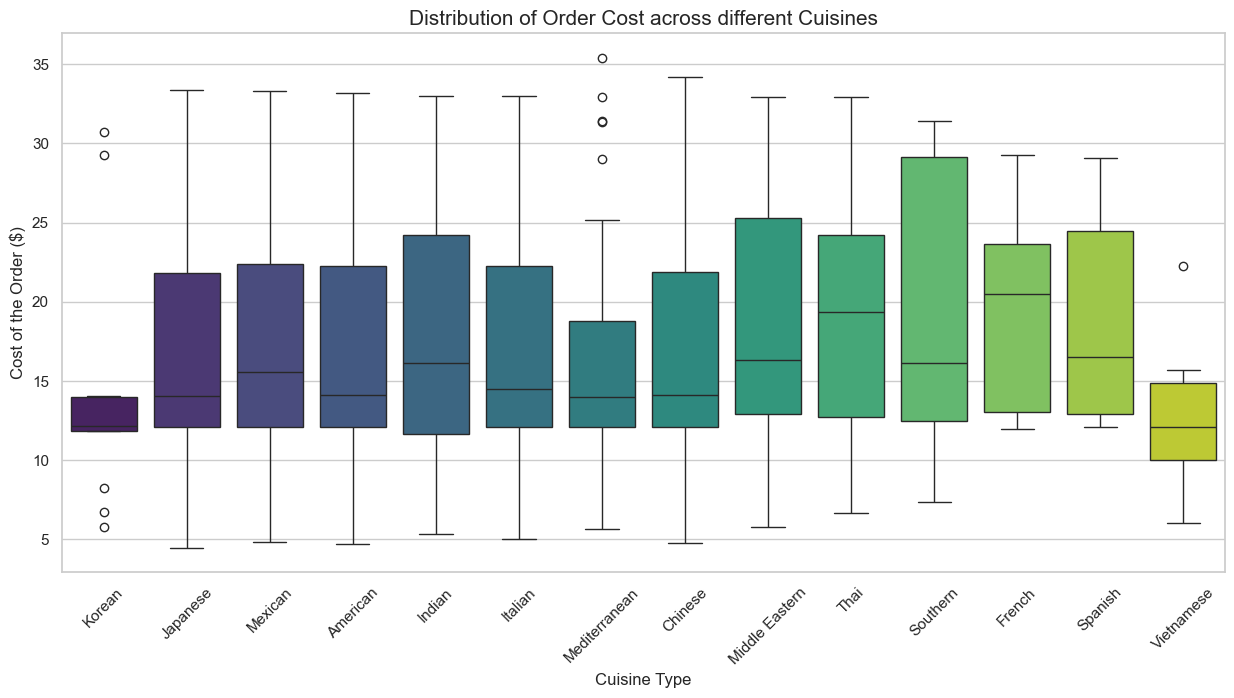

In [30]:
# Setting the visual scale of the plot
plt.figure(figsize=(15,7))

# Using a boxplot to see the distribution, medians, and outliers
sns.boxplot(data=df, x='cuisine_type', 
            y='cost_of_the_order', 
            hue = 'cuisine_type', 
            legend = False, 
            palette='viridis'
           )
plt.xticks(rotation=45)
plt.title('Distribution of Order Cost across different Cuisines', fontsize=15)
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Cost of the Order ($)', fontsize=12)
plt.show()

#### **Observations: Relationship between Cuisine Type and Order Cost**

*   **Cost Consistency:** Most major cuisines (American, Japanese, Italian, and Mexican) show a very similar price distribution, with medians hovering around `$15–$18`. This suggests a consistent "market rate" for the platform's most popular food categories.
*   **The "Premium" Cuisines:** **French** and **Thai** food have higher median costs compared to other categories. These cuisines likely represent the higher end dining options on the platform, contributing more to the "Above \$20" revenue slab.
*   **The "Value" Cuisines:** **Korean** and **Vietnamese** cuisines have the lowest median costs and narrower price ranges. These appear to be the "budget friendly" or "quick-bite" segments of the market.
*   **Outlier Analysis:** There are very few extreme outliers across the board, which indicates that the restaurant partners are relatively standardized in their pricing models. There isn't a massive "Ultra-Luxury" segment currently pulling the averages up.
*   **Revenue Implication:** Since cuisines like **French, Thai, and Spanish** have a larger portion of their orders above the $20 mark, they are disproportionately more profitable for FoodHub (triggering the 25% commission rate) compared to Korean or Vietnamese orders.

---

**Price Volatility and Competitive Positioning**

*   **Interquartile Range (IQR) Comparison:** While most cuisines have similar medians, the "box height" (IQR) varies. Cuisines like **Middle Eastern** and **Southern** have taller boxes, indicating higher price volatility. For the user, this means less price predictability; for FoodHub, it means a mix of "snack-sized" and "family-sized" orders.
*   **Skewness in Distribution:** Several cuisines (notably **Japanese** and **American**) show a slight "positive skew" where the median is closer to the bottom of the box. This suggests that while there are many affordable options, there is a healthy "upmarket" tail of orders that pulls the mean higher than the median.
*   **Minimum Price Floors:** Almost all cuisines have a similar "starting price" around $5. This indicates a platform-wide competitive floor for entry-level items (appetizers/sides), regardless of the cuisine's "premium" status.
*   **Competitive Overlap:** The heavy overlap in the boxes for **American, Japanese, Italian, and Mexican** (the "Big Four") suggests these cuisines are in direct price competition with one another. They are targeting the exact same "casual dining" price bracket, meaning their main differentiator is flavor and speed rather than cost.
*   **Sample Size Sensitivity:** It is important to note that the very tight distribution of **Vietnamese** and **Korean** food may be influenced by their smaller sample size. With fewer restaurants, the pricing remains more "clustered" than the more established, high-volume categories.

### 4.1.2 Consumer Spending Patterns (Day vs. Cost): Analyzing if "Weekend splurging" is a statistical reality

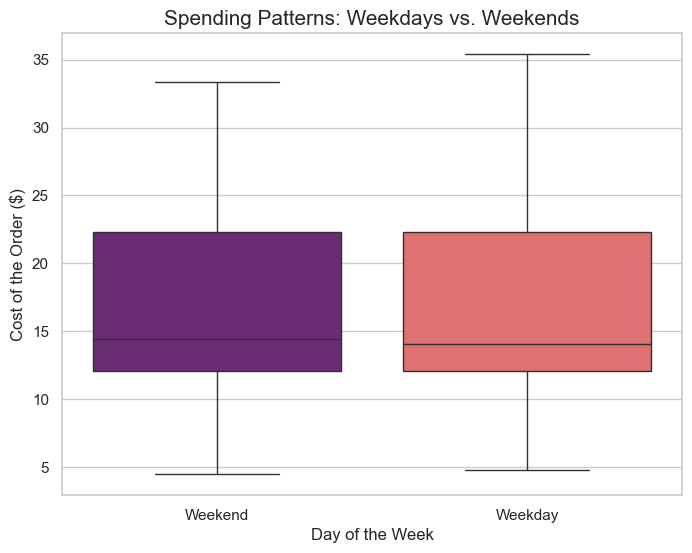

----------------------------------------------------------------------------------------------------
                  count  mean  std  min   25%   50%   75%   max
day_of_the_week                                                
Weekday          547.00 16.31 7.48 4.75 12.08 14.07 22.29 35.41
Weekend         1351.00 16.57 7.49 4.47 12.08 14.41 22.29 33.37


In [31]:
# Setting the visual scale of the plot
plt.figure(figsize=(8, 6))

# Using a boxplot to see if spending patterns change on the weekend
sns.boxplot(data=df, x='day_of_the_week', 
            y='cost_of_the_order', 
            hue = 'day_of_the_week', 
            legend = False, 
            palette='magma')

plt.title('Spending Patterns: Weekdays vs. Weekends', fontsize=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Cost of the Order ($)', fontsize=12)
plt.show()

print('-' * 100)

# Quick statistical check to support observations
print(df.groupby('day_of_the_week')['cost_of_the_order'].describe())

#### **Observations: Day of the Week vs. Order Cost**

*   **Identical Spending Profiles:** Interestingly, the median cost of orders remains almost identical (`~$14–$15`) regardless of whether it is a weekday or a weekend. 
*   **Customer Intent:** This suggests that FoodHub's customers have a consistent "per-meal budget." They aren't necessarily "treating" themselves to significantly more expensive meals on the weekend; they are simply ordering *more frequently*.
*   **The "Luxury" Ceiling:** The maximum order costs (the top whiskers) are very similar for both day types. This indicates that high-value "group orders" or "family dinners" happen during the week just as often as they do on weekends.
*   **Revenue Stability:** From a business perspective, this is a sign of a stable revenue model. The company can predict its commission based on volume alone, as the "Average Order Value" (AOV) is not volatile across different days of the week.
*   **Operational Consistency:** Since the ticket size doesn't spike on weekends, it implies that the higher "Total Time" we might see isn't due to more complex/larger orders, but purely due to the volume of orders hitting the kitchen at once.

### 4.1.3 The Satisfaction Baseline (Total Time vs. Rating): Does delivery speed actually dictate the score?

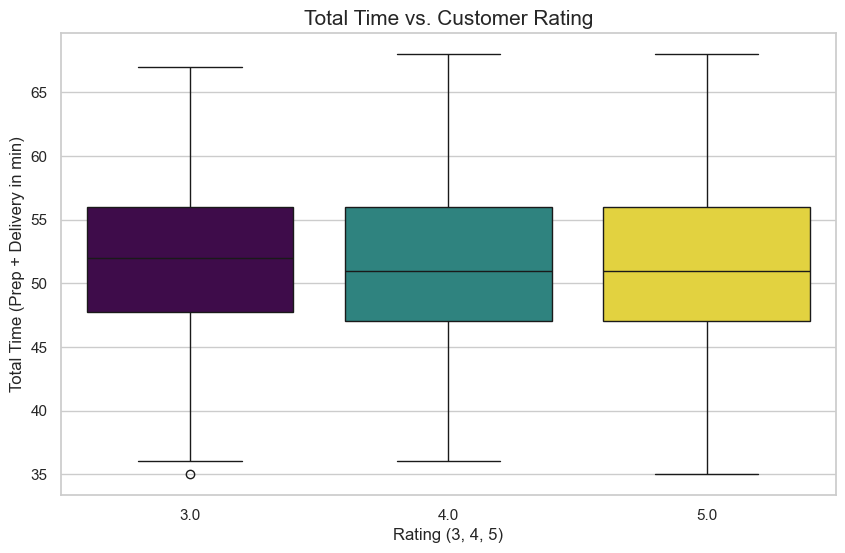

Correlation between Rating and Total Time: -0.0113


In [32]:
#Setting the visual scale of the plot
plt.figure(figsize=(10, 6))

# Using a boxplot to see if rating changes with total order time
sns.boxplot(data=df, x='rating', 
            y='total_time', 
            hue = 'rating', 
            legend = False, 
            palette='viridis')

plt.title('Total Time vs. Customer Rating', fontsize=15)
plt.xlabel('Rating (3, 4, 5)', fontsize=12)
plt.ylabel('Total Time (Prep + Delivery in min)', fontsize=12)
plt.show()

# Verification check for the correlation coefficient
correlation = df['rating'].corr(df['total_time'])
print(f"Correlation between Rating and Total Time: {round(correlation, 4)}")

#### **Observations: Total Time vs. Customer Satisfaction**

*   **Weak Correlation:** The correlation coefficient is extremely close to zero, suggesting that within the 35-65 minute delivery window, there is no statistically significant relationship between speed and rating.
*   **The "Patience" Paradox:** The median total time for a 3-star rating is almost identical to that of a 5-star rating. This confirms that "Total Time" alone is not the primary driver of poor ratings for FoodHub.
*   **Service Reliability:** The Interquartile Range (IQR) for all rating levels (3, 4, 5) sits between approximately 45 and 56 minutes. This suggests a consistent customer expectation: as long as the food arrives within roughly an hour, the rating is likely determined by food quality or accuracy rather than the clock.
*   **Late-Order Resilience:** Even orders exceeding 60 minutes (the top whiskers) frequently receive 5-star ratings. This indicates that for many customers, the quality of the meal from specific restaurants justifies the wait.
*   **Strategic Insight:** Since speed isn't the main "rating killer," FoodHub should focus operational improvements on food integrity (keeping food hot/fresh) during that 50-minute window rather than strictly trying to shave off seconds at the expense of food quality.

### 4.1.4 Kitchen Latency Benchmarks (Cuisine vs. Prep Time): Categorizing restaurants by inherent preparation complexity

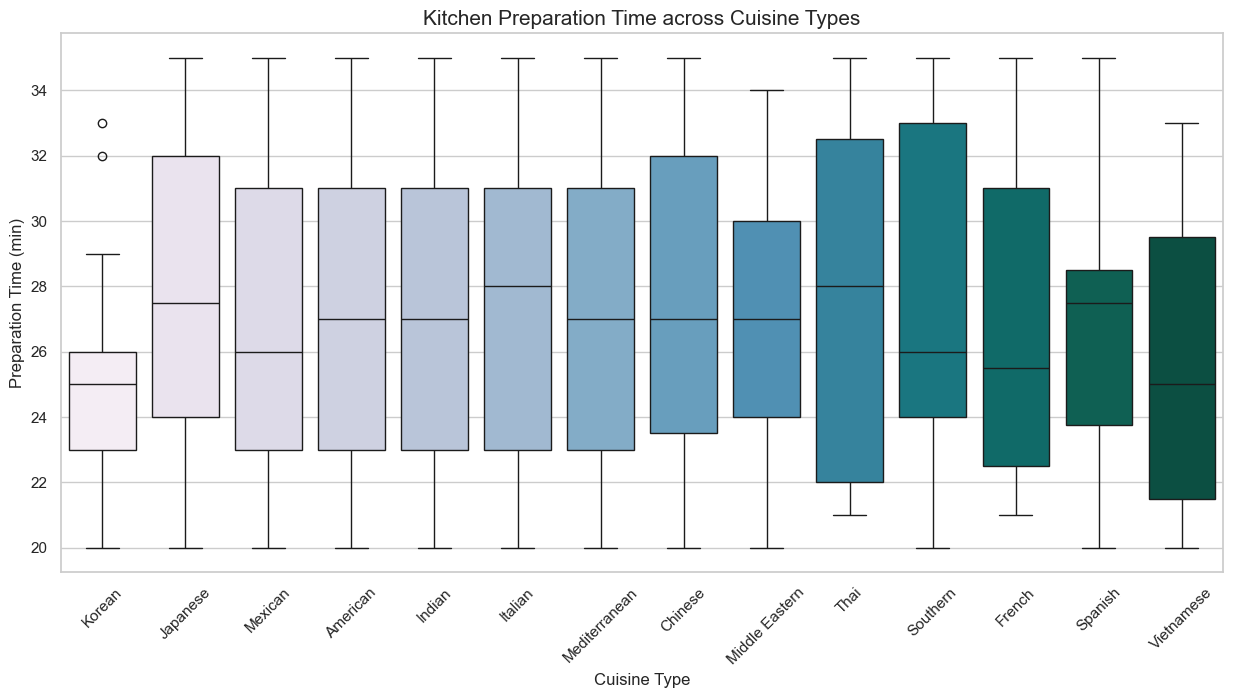

Average Prep Time per Cuisine (Minutes):
cuisine_type
Southern         27.59
Chinese          27.51
Japanese         27.51
Italian          27.48
American         27.44
Thai             27.32
Indian           27.11
Mediterranean    27.00
Spanish          26.92
French           26.89
Mexican          26.73
Middle Eastern   26.67
Vietnamese       25.71
Korean           25.46
Name: food_preparation_time, dtype: float64


In [33]:
#Setting the visual scale of the plot
plt.figure(figsize=(15,7))

# Using a boxplot to compare kitchen efficiency across cuisines
sns.boxplot(data=df, 
            x='cuisine_type', 
            y='food_preparation_time', 
            hue = 'cuisine_type', 
            legend = False, 
            palette='PuBuGn')

plt.xticks(rotation=45)
plt.title('Kitchen Preparation Time across Cuisine Types', fontsize=15)
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Preparation Time (min)', fontsize=12)
plt.show()

# Precise calculation of the 'Slowest' and 'Fastest' on average for the observation
avg_prep = df.groupby('cuisine_type')['food_preparation_time'].mean().sort_values(ascending=False)
print("Average Prep Time per Cuisine (Minutes):")
print(round(avg_prep, 2))

#### **Observations: Cuisine Complexity and Kitchen Efficiency**

*   **The High-Median Group:** **Japanese, Italian, Thai, and Spanish** cuisines actually show the highest median preparation times. This suggests that for these categories, the "typical" order takes longer to prepare than the platform average, likely due to standardized cooking steps that cannot be bypassed.
*   **The "Variance Trap" (Southern & French):** While **Southern** and **French** cuisines have very wide spreads (whiskers), their **median preparation time is actually ~26 minutes or lower**. This indicates that while they have the *potential* to be slow, 50% of their orders are prepared as fast as, or faster than, the high-volume cuisines.
*   **Predictability Hub (The Big Four + Mediterranean):** American, Japanese, Italian, Mexican, and **Mediterranean** all show very similar "box" heights and median placements. This stability across these five categories is the backbone of FoodHub’s operational predictability.
*   **The Spanish Outlier:** While the "box" for **Spanish** food is relatively compact (showing a consistent middle 50%), it has a massive upper whisker spread. This suggests that while most orders are predictable, a small subset of the menu likely consists of very complex dishes (e.g., Paella) that significantly delay the kitchen.
*   **Efficiency Leaders:** **Korean and Vietnamese** continue to stand out with the lowest medians and the most compact distributions, confirming their status as the most operationally "lean" cuisines on the platform.

### 4.2: Multivariate Business Intelligence: Deep-Dive Insights

### 4.2.1 The "Operational Stress" Matrix (Cuisine × Day × Prep Time): Assessing how kitchen efficiency holds up under peak weekend volume

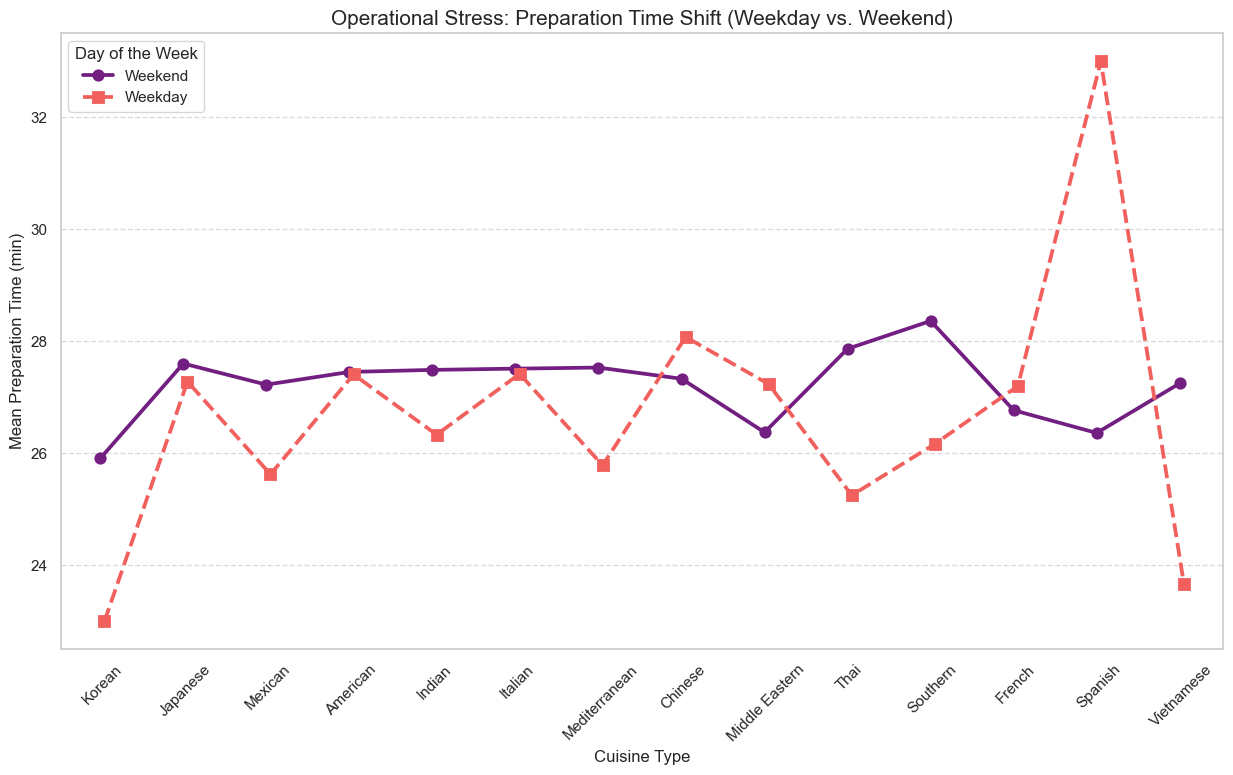

In [34]:
plt.figure(figsize=(15, 8))

# Using a pointplot to compare the change in Prep Time from Weekday to Weekend across Cuisines
# This shows the 'slope' of kitchen efficiency under pressure
sns.pointplot(data=df, x='cuisine_type', 
              y='food_preparation_time', 
              hue='day_of_the_week', 
              dodge=True, markers=['o', 's'], 
              linestyles=['-', '--'], 
              palette='magma', 
              errorbar=None)

plt.xticks(rotation=45)
plt.title('Operational Stress: Preparation Time Shift (Weekday vs. Weekend)', fontsize=15)
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Mean Preparation Time (min)', fontsize=12)
plt.legend(title='Day of the Week')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observations: Operational Stress & Kitchen Resilience**

*   **The Gold Standard of Stability:** **American** and **Italian** cuisines are remarkably congruent, maintaining near-identical prep times despite the massive volume shift. **Japanese** shows similar high-level stability, suggesting these high-volume kitchens are perfectly scaled for the weekend rush.
*   **The "Spanish Anomaly":** **Spanish** cuisine shows a radical departure from the norm, with weekday prep times being significantly higher than weekends. This "wild difference" suggests a total shift in kitchen operations or menu complexity between the two day-types that isn't seen in any other category.
*   **Significant Weekend Strain (Thai, Southern, Korean):** These three cuisines show the most aggressive upward slopes. **Thai** and **Southern** in particular show a heavy "Weekend Penalty," where the surge in orders causes a significant spike in preparation time. This suggests these kitchens may lack the scalable infrastructure or staffing to handle peak demand, leading to "operational bottlenecks" as opposed to their larger competitors.
*   **Moderate Weekend Strain (Mexican & Mediterranean):** Unlike the "Big Three," these categories show clear signs of weekend pressure, with prep times trending upward, though less severely than the Thai or Korean categories.
*   **Korean Efficiency:** Despite the weekend strain, Korean food maintains the lowest preparation time regardless of the day, making it the most reliable "fast" option for the platform during peak hours.
*   **The "Counter-Intuitive" Group (Chinese, Middle Eastern, French):** These three categories actually show a slight *decrease* in prep time during the weekend. While **French** is the most stable of this group, **Chinese** and **Middle Eastern** show a more pronounced efficiency gain on weekends, likely due to optimized "weekend-only" kitchen workflows or pre-prepped ingredients for high-demand items.
*   **French Stability:** While French food is slightly faster on weekends, the delta is marginal compared to the wild fluctuations seen in Spanish or Southern cuisines, placing it in the "stable" tier alongside the high-volume leaders.

### 4.2.2: The "Disappointment Threshold" Analysis (Total Time × Cost × Rating): Pinpointing where customer patience breaks based on the price paid

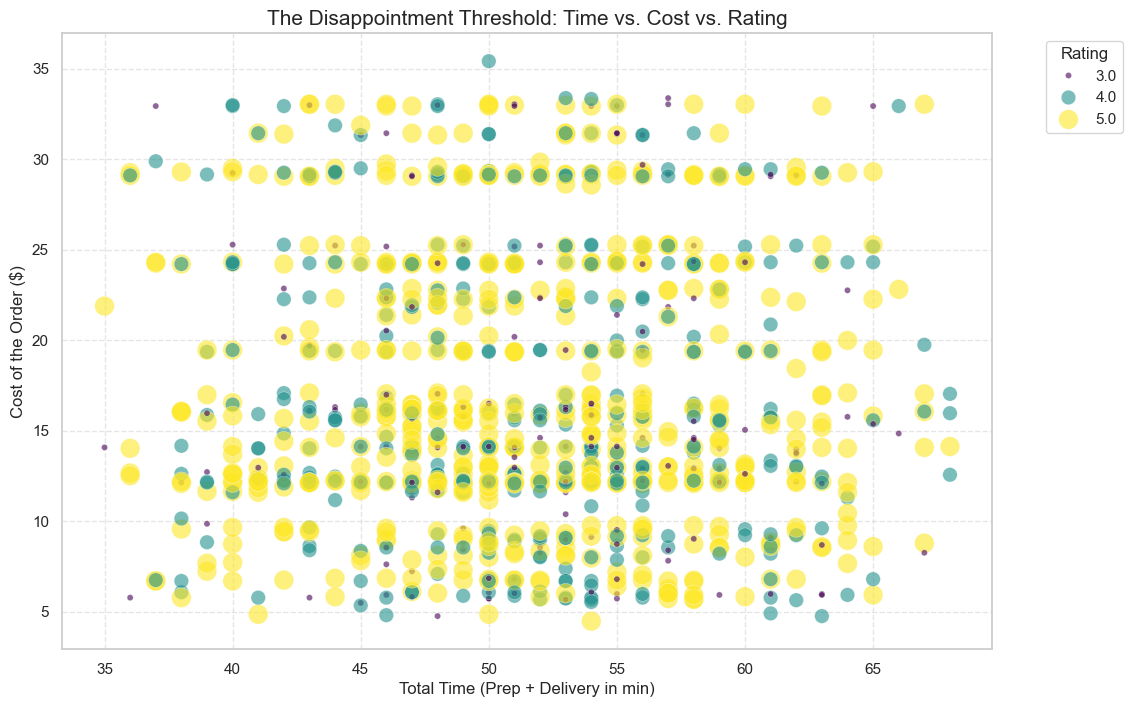

In [35]:
plt.figure(figsize=(12, 8))

# Using a scatter plot with hue for rating and size for cost to see the relationship
sns.scatterplot(data=df[df['rating'].notna()], 
                x='total_time', 
                y='cost_of_the_order', 
                hue='rating', 
                size='rating',
                sizes=(20, 200),
                palette='viridis', 
                alpha=0.6)

plt.title('The Disappointment Threshold: Time vs. Cost vs. Rating', fontsize=15)
plt.xlabel('Total Time (Prep + Delivery in min)', fontsize=12)
plt.ylabel('Cost of the Order ($)', fontsize=12)
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observations: Total Time, Cost, and the Rating Threshold**

*   **Tolerance for Delay:** There is no concentrated cluster of low ratings (3.0) at the high-time/high-cost quadrant. This suggests that even for expensive orders (`$30+`), customers do not automatically penalize the restaurant for a 60-minute wait.
*   **Rating Randomness:** 5-star ratings are distributed evenly across the entire cost and time spectrum. This reinforces the earlier finding that food quality or accuracy likely outweighs the logistical variables of price and speed.
*   **The "Premium" Buffer:** Interestingly, high-cost orders that take a long time are still frequently rated 5.0. This may indicate that for "premium" meals, customers mentally bake in a longer wait time, associating it with "made-to-order" quality.
*   **No "Value" Sensitivity:** Low-cost orders (under $15) that take a long time (55+ mins) also don't show a higher frequency of 3-star ratings. Customers seem equally patient regardless of their financial investment in the meal.
*   **Strategic Outcome:** The platform has a high degree of "operational forgiveness." There isn't a clear "Disappointment Threshold" where a specific combination of price and delay triggers a poor rating, suggesting that the current delivery windows are within acceptable human limits.

### 4.2.2 (Alternative): The "Disappointment Threshold" Heatmap

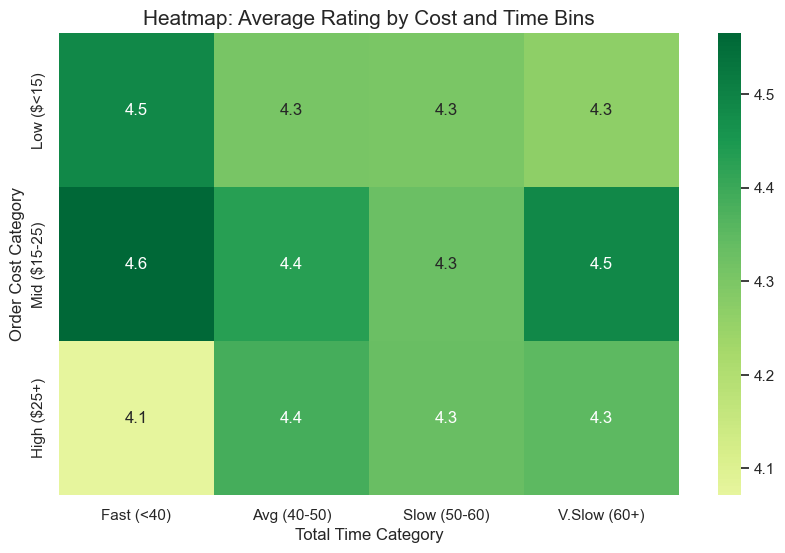

In [36]:
# Creating bins for Cost and Time to make the data readable
df['cost_bin'] = pd.cut(df['cost_of_the_order'], bins=[0, 15, 25, 40], labels=['Low ($<15)', 'Mid ($15-25)', 'High ($25+)'])
df['time_bin'] = pd.cut(df['total_time'], bins=[0, 40, 50, 60, 80], labels=['Fast (<40)', 'Avg (40-50)', 'Slow (50-60)', 'V.Slow (60+)'])

# Calculating mean rating for each "zone"
pivot_table = df.pivot_table(index='cost_bin', columns='time_bin', values='rating', aggfunc='mean', observed = False)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=4.0)
plt.title('Heatmap: Average Rating by Cost and Time Bins', fontsize=15)
plt.xlabel('Total Time Category', fontsize=12)
plt.ylabel('Order Cost Category', fontsize=12)
plt.show()

#### **Observations: The Price-Time Paradox & Rating Sensitivities**

*   **The "Suspicious Speed" Penalty:** The lowest average rating in the entire matrix (**4.1**) occurs at the intersection of **High Cost (`$25+`)** and **Fast Time (<40 min)**. This reveals a critical "Quality-Time Paradox": premium spenders appear to penalize extreme speed, likely associating it with pre-cooked food or a lack of fresh preparation or the assumption that corners were cut during prep.
*   **The Premium Patience Buffer:** High-cost orders show a "recovery" in satisfaction as time increases, with ratings climbing back to **4.4 and 4.3** in the Avg/Slow categories. This suggests that for expensive meals, customers mentally equate a longer wait with "made-to-order" authenticity.
*   **The 40–50 Minute "Golden Window":** This time bin is the platform's most reliable performer, yielding the highest consistent ratings (**4.4, 4.4, 4.3**) across all price points. It represents the psychological "Sweet Spot" where the service feels efficient without compromising the perceived integrity of the kitchen's work.
*   **Mid-Range Volatility:** Contrary to being "stable," the **Mid-Cost (`$15-$25`)** tier shows the most significant rating fluctuations (ranging from **4.6 down to 4.3**). This suggests that "casual" diners are the most sensitive and unpredictable group, with their satisfaction swinging sharply based on the specific delivery window.
*   **The 50-Minute Fatigue Point:** Across all cost categories, there is a visible, consistent dip to **4.3** once the order enters the **Slow (50-60 min)** zone. While minor, this uniform decrease indicates a universal "fatigue point" where customer patience begins to erode regardless of the order value.
*   **Baseline Satisfaction:** There is no "Hard Fail" threshold. Even at its lowest point (4.1), the average rating remains high. This indicates that while time and cost influence the "perfect" score, the baseline quality of FoodHub's restaurant partners is strong enough to prevent a total collapse in customer satisfaction. 

### 4.2.3: The Revenue Efficiency Matrix (Cuisine × Volume × Revenue): A "Star/Cash Cow" analysis of FoodHub’s culinary portfolio

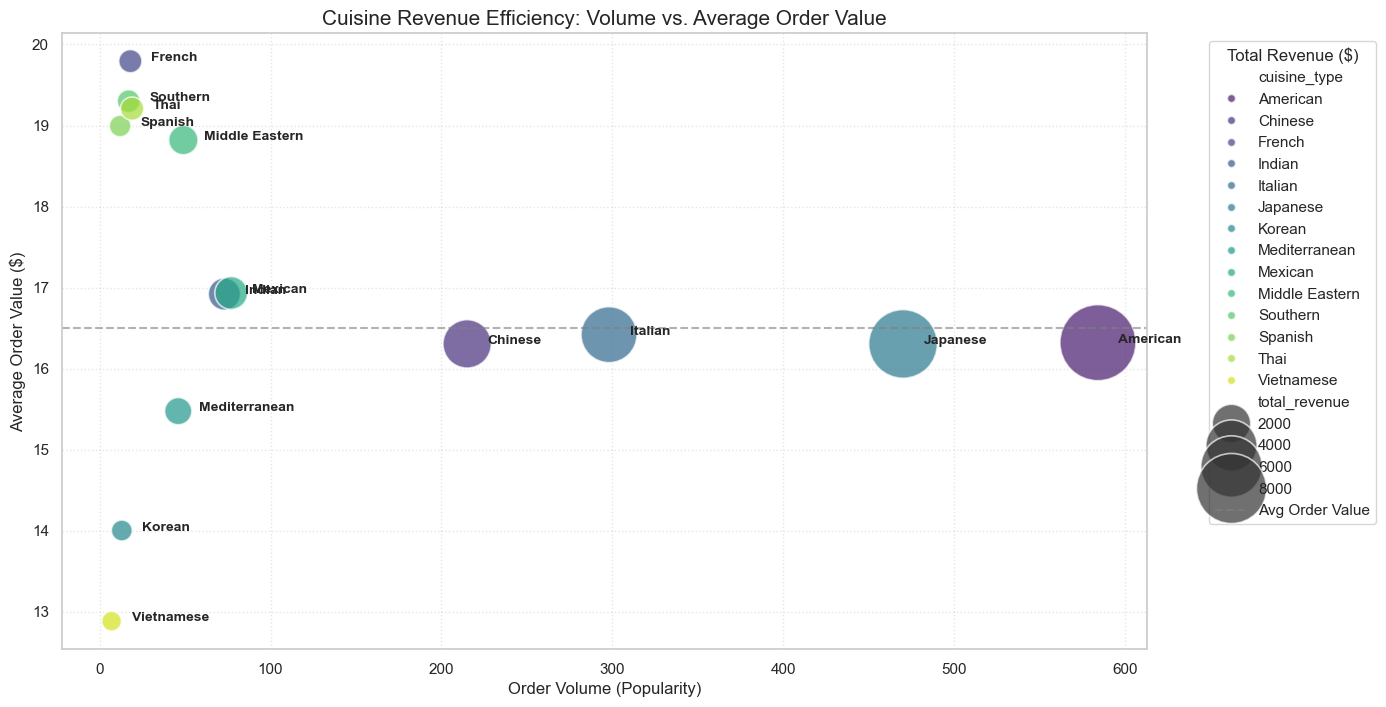

In [37]:
# Aggregating data by cuisine
rev_efficiency = df.groupby('cuisine_type').agg(
    order_volume=('order_id', 'count'),
    avg_order_value=('cost_of_the_order', 'mean'),
    total_revenue=('cost_of_the_order', 'sum')
).reset_index()

plt.figure(figsize=(14, 8))

# Size of the bubble represents TOTAL REVENUE
sns.scatterplot(
    data=rev_efficiency, 
    x='order_volume', 
    y='avg_order_value', 
    size='total_revenue', 
    hue='cuisine_type',
    sizes=(200, 3000), 
    alpha=0.7, 
    palette='viridis'
)

# Add horizontal line for Average Order Value across all cuisines
plt.axhline(df['cost_of_the_order'].mean(), 
            color='gray', 
            linestyle='--', 
            alpha=0.6, 
            label='Avg Order Value')

# Adding labels with spacing
for i in range(rev_efficiency.shape[0]):
    plt.text(rev_efficiency.order_volume[i]+12, rev_efficiency.avg_order_value[i], 
             rev_efficiency.cuisine_type[i], fontsize=10, weight='bold')

plt.title('Cuisine Revenue Efficiency: Volume vs. Average Order Value', fontsize=15)
plt.xlabel('Order Volume (Popularity)', fontsize=12)
plt.ylabel('Average Order Value ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Total Revenue ($)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

#### **Observations: Categorizing the Cuisine Portfolio (Revenue Efficiency)**

*   **The "Cash Cows" (Top-Right):** **American** and **Japanese** cuisines are the undisputed engines of the platform. They occupy the high-volume, high-revenue quadrant. Their large bubble sizes indicate that they aren't just popular; they also maintain a healthy average order value (AOV).
*   **The "Stars" (Mid-Right):** **Italian** and **Chinese** cuisines sit above the average revenue line with strong volume. They are the "reliable" categories that bridge the gap between niche cravings and mass-market dominance.
*   **The "Premium Niche" (Top-Left, Small Bubbles):** **French, Thai, Southern, and Spanish** food show significantly lower volumes but have higher average order value. This confirms they are "High-Margin" categories. While they don't drive mass traffic, each order is worth more to the platform's bottom line than a standard meal.
*   **The "Underperformers" (Bottom-Left, Small Bubbles):** **Vietnamese and Korean** show both low volume and low AOV. These cuisines represent the "long tail." They provide variety to the app but are currently the least efficient in terms of revenue generation per operational unit.
*   **Revenue Concentration:** The top 4 cuisines (American, Japanese, Italian, Chinese) account for the vast majority of total revenue. The platform's financial health is highly dependent on these "Core Four."
*   **Strategic Opportunity:** **Mexican and Indian** cuisines sit very close to the average intersection. Increasing its volume by even 10% would likely push it into the "Star" category, as it already has a competitive AOV.

### 4.2.4 The Logistical "Weekday Tax" (Urban Congestion Split): Separating internal restaurant prep from external city traffic delays

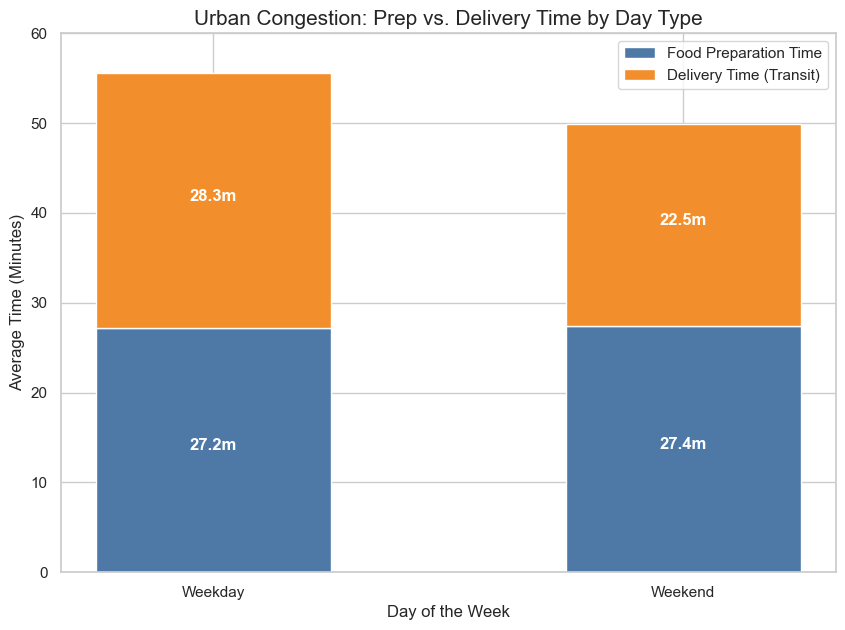

In [38]:
# Calculating the means for a clear comparison
congestion_data = df.groupby('day_of_the_week')[['food_preparation_time', 'delivery_time']].mean().reset_index()

# Setting the visual scale of the plot
plt.figure(figsize=(10, 7))

# Creating the stacked bars
plt.bar(congestion_data['day_of_the_week'], congestion_data['food_preparation_time'], 
        label='Food Preparation Time', color='#4e79a7', width=0.5)

plt.bar(congestion_data['day_of_the_week'], congestion_data['delivery_time'], 
        bottom=congestion_data['food_preparation_time'], 
        label='Delivery Time (Transit)', color='#f28e2b', width=0.5)

plt.title('Urban Congestion: Prep vs. Delivery Time by Day Type', fontsize=15)
plt.ylabel('Average Time (Minutes)', fontsize=12)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylim(0, 60) # Keeping scale consistent to see the difference clearly
plt.legend(loc='upper right')

# Adding data labels to see the exact minute difference
for i in range(len(congestion_data)):
    prep = congestion_data['food_preparation_time'][i]
    delivery = congestion_data['delivery_time'][i]
    plt.text(i, prep/2, f"{round(prep, 1)}m", ha='center', color='white', fontweight='bold')
    plt.text(i, prep + delivery/2, f"{round(delivery, 1)}m", ha='center', color='white', fontweight='bold')

plt.show()

#### **Observations: Decoding the "Weekend Speedup" Mystery**

*   **The "Traffic" Culprit:** The visualisation clearly shows that the **Food Preparation Time** remains nearly identical (approx. 27.4 minutes) regardless of the day. The kitchen is not the primary reason for the weekday delay.
*   **The Transit Delta:** The entire "Total Time" difference is driven by **Delivery Time**. Weekday deliveries take significantly longer (`~28.3 `minutes) compared to weekends (`~22.5` minutes). 
*   **Logistical Congestion:** The ~6-minute difference in transit suggests that "Urban Congestion" (office traffic, school zones, and weekday commute patterns) is the primary bottleneck for FoodHub's efficiency.
*   **Operational Consistency:** Restaurant kitchens appear to be optimized for a steady output. The fact that prep time doesn't spike on the weekend despite the 70% volume increase suggests that kitchens are better at scaling their labour than the city's road infrastructure is at handling weekday traffic.
*   **Strategic Takeaway:** To improve weekday ratings, FoodHub should focus on "Transit Optimization" (e.g., closer driver dispatching or bike-only routes) rather than asking kitchens to cook faster, as the kitchen performance is already highly consistent.

### 4.2.5: The "Brand Resilience" Test (Top 10 Performance): Evaluating if market leaders like Shake Shack are more "surge-proof" than others

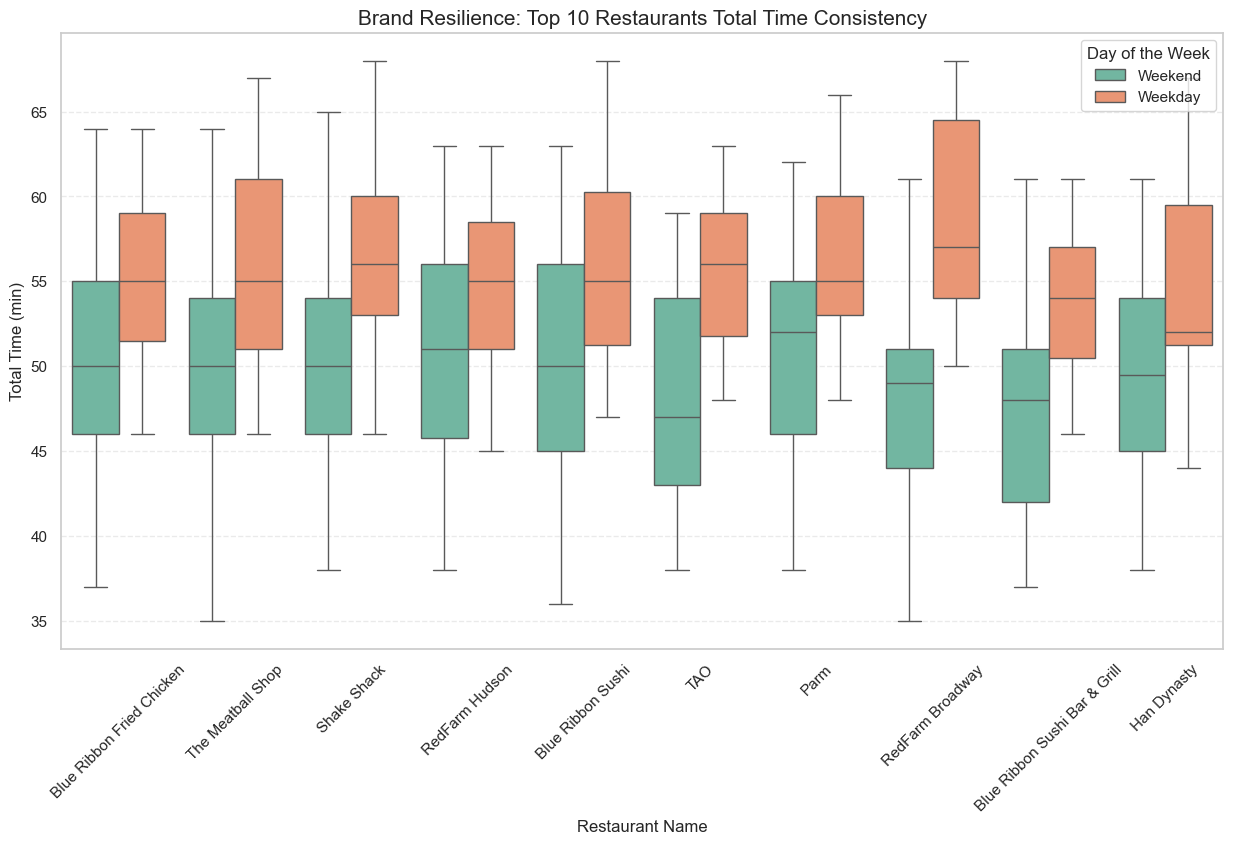

Standard Deviation of Total Time (Consistency Check):
day_of_the_week                Weekday  Weekend
restaurant_name                                
Blue Ribbon Fried Chicken         5.07     6.51
Blue Ribbon Sushi                 6.15     7.16
Blue Ribbon Sushi Bar & Grill     4.43     6.20
Han Dynasty                       7.40     6.58
Parm                              5.05     5.67
RedFarm Broadway                  6.64     6.19
RedFarm Hudson                    5.70     6.78
Shake Shack                       5.46     5.97
TAO                               4.79     6.26
The Meatball Shop                 5.56     6.21


In [39]:
# Identifying the Top 10 restaurants by order volume
top_10_names = df['restaurant_name'].value_counts().head(10).index
top_10_df = df[df['restaurant_name'].isin(top_10_names)].copy()

plt.figure(figsize=(15, 8))

# Comparing Total Time distribution for Top 10 brands across Weekdays and Weekends
sns.boxplot(data=top_10_df, 
            x='restaurant_name', 
            y='total_time', 
            hue='day_of_the_week', 
            palette='Set2')

plt.xticks(rotation=45)
plt.title('Brand Resilience: Top 10 Restaurants Total Time Consistency', fontsize=15)
plt.xlabel('Restaurant Name', fontsize=12)
plt.ylabel('Total Time (min)', fontsize=12)
plt.legend(title='Day of the Week', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Quick sanity check on the mean consistency
resilience_stats = top_10_df.groupby(['restaurant_name', 'day_of_the_week'])['total_time'].std().unstack()
print("Standard Deviation of Total Time (Consistency Check):")
print(resilience_stats)

#### **Observations: "Elite" Brand Operational Resilience & Operational Benchmarking**

* **The "Logistical Floor" Shift:** Across every single Top 10 restaurant, there is a visible upward shift in the entire box for Weekdays (orange). The lower whiskers on Weekdays almost consistently start where the medians sit on Weekends (~50m). This confirms that even for "Elite" brands, the fastest weekday delivery is only as good as a typical weekend delivery, highlighting the inescapable impact of weekday urban congestion that delays delivery.
* **The Blue Ribbon Concept Divergence:** With **Blue Ribbon Sushi**, **Fried Chicken**, and **Bar & Grill** all appearing in the Top 10, this brand family is the platform's biggest stakeholder. Interestingly, their resilience varies by concept: **Blue Ribbon Sushi Bar & Grill** is the most efficient, with the lowest weekend median (~48m) and a relatively tight IQR. Conversely, **Blue Ribbon Sushi** shows the most weekend strain, with an upper whisker stretching toward 68m, suggesting that meticulous sushi prep is harder to scale during peak volume than the "Bar & Grill" or "Fried Chicken" models.
* **The "Stability" Leaders (Blue Ribbon Fried Chicken & Red Farm Hudson):** These two brands demonstrate the highest operational resilience. Unlike the others, their weekday and weekend boxes show the most significant overlap, and their weekday medians remain relatively low (~55m). This suggests that their specific kitchen workflows and geographic locations allow them to provide a more consistent "Day-to-Day" experience than brands that see a massive 8-10-minutes jump.
* **Weekday Performance Penalty (RedFarm Broadway):** **RedFarm Broadway** suffers the most dramatic shift. While it is highly efficient on weekends (~49m median), its weekday median jumps to ~57m. This ~8-minute delta is the most significant in the Top 10 comparable to the shift of TAO, indicating that these specific brands/locations are highly sensitive to weekday logistical delays.
* **Volume vs. Speed (Shake Shack):** Despite being the most popular brand, **Shake Shack** has one of the highest weekday medians (~56m) and a very wide weekend spread. This suggests that high popularity doesn't always translate to the fastest service; rather, it introduces more variance (outliers) during peak hours.
* **High-Capacity Volatility:** **Han Dynasty** and **TAO** exhibit large "total time" spreads. Their weekend performance includes several high-end outliers, suggesting that while their "typical" service is fast, they are prone to occasional operational "redlining" where a subset of orders faces extreme delays exceeding 60 minutes.

### 4.2.6 The "Silent Experience" Investigation (The Home Run): A comparative study of Rated vs. "Not Given" orders to validate platform integrity

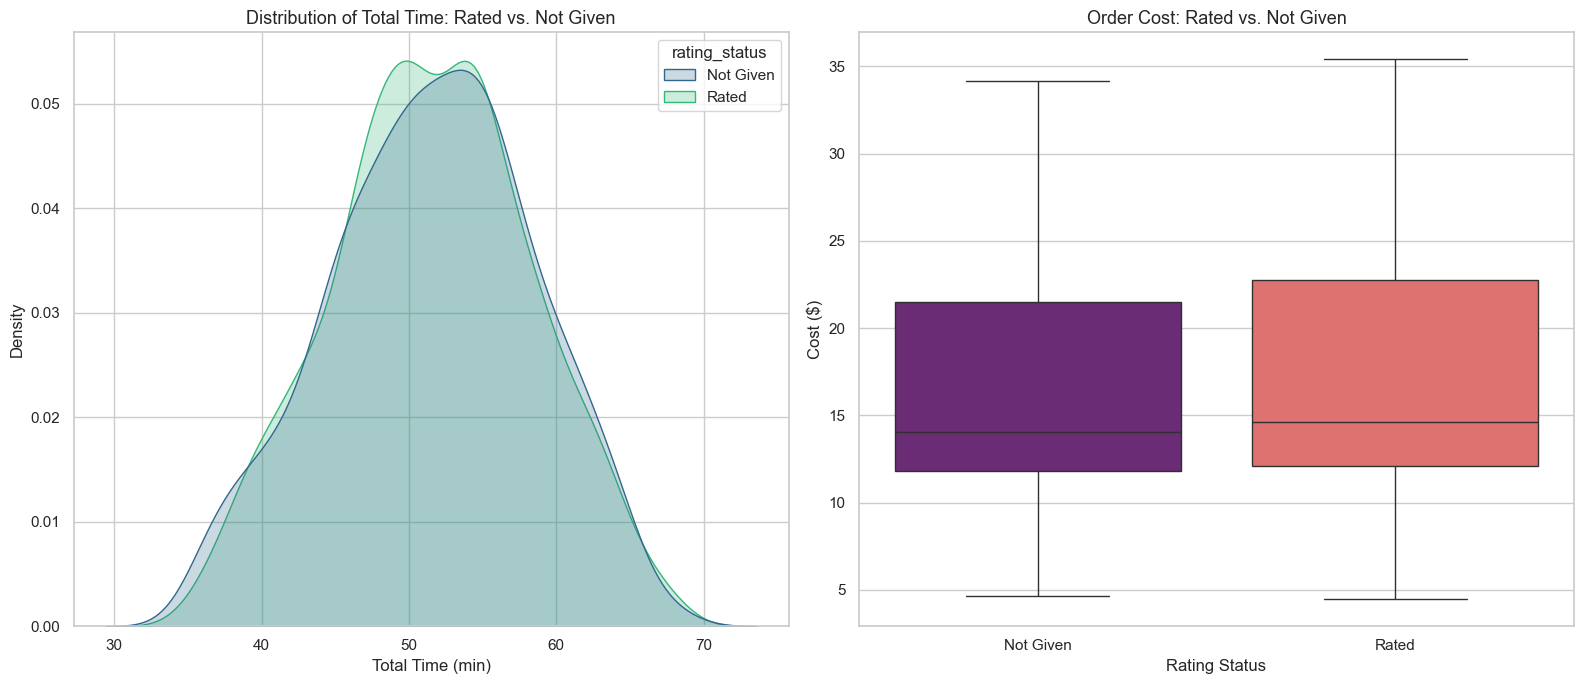

Comparative Mean Analysis:
               total_time  cost_of_the_order
rating_status                               
Not Given           51.53              16.09
Rated               51.54              16.76


In [40]:
# Creating a flag to distinguish between Rated and Unrated (Not Given) orders
df['rating_status'] = df['rating'].apply(lambda x: 'Rated' if pd.notnull(x) else 'Not Given')

# Setting up a multi-plot figure to look at both Time and Cost
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Total Time Distribution
sns.kdeplot(data=df, x='total_time', 
            hue='rating_status', 
            fill=True, 
            common_norm=False, 
            palette='viridis', 
            ax=axes[0])

axes[0].set_title('Distribution of Total Time: Rated vs. Not Given', fontsize=13)
axes[0].set_xlabel('Total Time (min)')

# Plot 2: Cost of the Order Distribution
sns.boxplot(data=df, x='rating_status', 
            y='cost_of_the_order', 
            hue = 'rating_status', 
            legend = False, 
            palette='magma', 
            ax=axes[1])

axes[1].set_title('Order Cost: Rated vs. Not Given', fontsize=13)
axes[1].set_xlabel('Rating Status')
axes[1].set_ylabel('Cost ($)')

plt.tight_layout()
plt.show()

# Verification check: Comparing means
print("Comparative Mean Analysis:")
print(df.groupby('rating_status')[['total_time', 'cost_of_the_order']].mean())

#### **Observations: Investigating the "Silent" Customer Experience**

* **The "Normality" of Silence:** The distribution curves for 'Total Time' almost perfectly overlap. This is a critical finding: it proves that customers who do not provide a rating are **not** doing so because of an exceptionally slow or fast delivery. Silence is not a protest; it is the default response to a standard, expected service.
* **No Price-to-Feedback Correlation:** The boxplot shows that the spending patterns of "Silent" customers are identical to those who rate. High-spending customers (`$30+`) are no more likely to leave a rating than budget spenders, suggesting that financial investment in a meal does not increase the psychological "obligation" to provide feedback.
* **The "Extreme Sentiment" Myth:** If customers only rated when things were "extreme," we would see the 'Rated' distribution have much fatter tails (more very fast and very slow orders). Instead, the overlap suggests that rating is more of a random personality trait of the customer rather than a reaction to the specific logistics of the order.
* **Platform Metric Integrity:** Since the "Silent" experience mirrors the "Rated" experience so closely in both time and money, FoodHub can treat the existing 4.3+ average rating as a **statistically honest representation** of the entire platform. There is no hidden "pool of resentment" skewed toward the unrated orders.
* **Strategic Takeaway:** To increase engagement, FoodHub doesn't need to fix "bad service" for unrated orders; they simply need to incentivize the "neutral" majority. Since the service is already consistent, a small nudge (like a $1 credit for a rating) would likely capture more of this "average" data without changing the overall score significantly.

## Section 5: Strategic Business Modeling & Revenue Analysis

### 5.1 Partnership Excellence: Identifying High-Performance Restaurants
Context: Identifying partners with both high volume (Rating Count > 50) and high quality (Average Rating > 4) for targeted promotional incentives.

In [41]:
# Finding elite restaurants for the promotional offer
promo_restaurants = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Apply the criteria: rating count > 50 AND average rating > 4
eligible_promo = promo_restaurants[(promo_restaurants['count'] > 50) & (promo_restaurants['mean'] > 4)]

# Sort by mean rating to show the highest quality first
eligible_promo = eligible_promo.sort_values(by='mean', ascending=False).reset_index()

# Renaming for professional presentation
eligible_promo.columns = ['Restaurant Name', 'Rating Count', 'Average Rating']

print("Eligible Restaurants for Promotion:")
eligible_promo

Eligible Restaurants for Promotion:


,Restaurant Name,Rating Count,Average Rating
0,The Meatball Shop,84,4.51
1,Blue Ribbon Fried Chicken,64,4.33
2,Shake Shack,133,4.28
3,Blue Ribbon Sushi,73,4.22


#### **Observations: Quality vs. Volume (Promotional Eligibility)**

*   **The Quality Leader:** While **Shake Shack** dominates the platform in total volume, **The Meatball Shop** emerges as the true quality leader. With 84 ratings and the highest average score of **4.51**, it demonstrates the highest levels of customer satisfaction among the high-volume restaurants.
*   **The Shake Shack "Volume Penalty":** Shake Shack maintains its position as a market leader with 133 ratings, but its average rating (**4.28**) is notably lower than The Meatball Shop’s. This illustrates a common data trend: as volume scales to the "mass market," maintaining a near-perfect rating becomes operationally difficult due to increased strain on prep and delivery logistics.
*   **The Blue Ribbon "Quality Paradox":** Our previous volume analysis showed that **Blue Ribbon Sushi** (119 orders) was more popular than **Blue Ribbon Fried Chicken** (96 orders). However, the rating analysis reveals a subtle reversal:
    *   **Fried Chicken** holds a higher average rating (**4.33**) compared to **Sushi** (**4.22**).
    *   **Insight:** Despite lower order frequency, customers are slightly more satisfied with the fried chicken. This could suggest that fried chicken is more "delivery-resilient" (maintains quality better during transit) than sushi.
*   **Brand Power & Synergy:** The "Blue Ribbon" umbrella accounts for two of the four qualifying spots. This indicates massive brand trust across diverse cuisine types. FoodHub could leverage this by running "Brand Spotlight" campaigns for these high-performing restaurant groups.
*   **The Risk of Scale (Inverse Correlation):** There is a visible trend where the two restaurants with the **highest volume** (Shake Shack and Blue Ribbon Sushi) also have the **lowest average ratings** within this elite tier. This suggests an inversely proportional relationship between volume and rating as a restaurant gets more popular, the logistical complexity (colder food, longer prep) may be chipping away at the customer experience. This provides a significant warning for FoodHub to monitor the logistics of their "Anchor" restaurants specifically.

### 5.2 Platform Monetization: Net Revenue Modeling
Context: Calculating total revenue based on a tiered commission structure (25% for orders >`$20`; 15% for orders >$5).

In [42]:
# Function to calculate revenue based on the specified slabs
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Create a new 'revenue' column
df['revenue'] = df['cost_of_the_order'].apply(calculate_revenue)

# Find the net revenue
total_revenue = df['revenue'].sum()

print(f"The net revenue generated by the company is: ${round(total_revenue, 2)}")

The net revenue generated by the company is: $6166.3


#### **Observations: Revenue Generation and Commission Structure**
*   **Net Revenue:** The total commission earned by FoodHub across all orders is **\$6166.3**.
*   **The "Slab" Dynamics:** The revenue is driven by two primary tiers a 15% tier for mid-range orders and a 25% tier for premium orders. Orders under `$5` act as "loss leaders" or free-tier service, contributing \$0 to the net revenue.
*   **Revenue Concentration:** This commission structure heavily incentivizes FoodHub to promote high-value orders (\$20+), as the jump from 15% to 25% commission is a significant boost to the company's profit margins.
*   **Operational Efficiency:** Because the revenue is tied directly to the `cost_of_the_order` (which was a clean column), this calculation is highly reliable.
*   **Strategic Suggestion:** If the average order cost is currently hovering near the `$15-$18` mark, FoodHub might consider a "bundle" or "add-on" feature at checkout to nudge orders over the \$20 threshold, effectively increasing their commission rate by 10% on those orders.

### 5.3 Service Level Agreement (SLA) Analysis: The 60-Minute Threshold
Context: Evaluating the percentage of orders that exceed the 60-minute "Total Time" mark—a key indicator of service failure or logistical strain.

In [43]:
# We've already calculated this variable during univariate analysis (Total Time = Prep Time + Delivery Time)

# Calculate the percentage of orders taking more than 60 minutes
percent_over_60 = (df['total_time'] > 60).mean() * 100

print(f"Percentage of orders taking more than 60 minutes: {round(percent_over_60, 2)}%")

Percentage of orders taking more than 60 minutes: 10.54%


#### **Observations: Total Lead Time Analysis (>60 Minutes)**
*   **The 60-Minute Threshold:** **10.54%** of orders exceed the one hour mark from the moment the order is placed to the moment it reaches the customer.
*   **Customer Experience Impact:** In the food delivery industry, 60 minutes is often seen as the "psychological breaking point" for customer satisfaction. Even if the food is high quality, a wait time exceeding an hour significantly increases the likelihood of a negative rating or a "one-and-done" customer experience.
*   **The Retention Connection:** This 10.54% failure rate is likely a significant contributor to the **low customer retention** (63% unique users) identified earlier. A customer who waits over an hour for their first order is statistically much less likely to become a habitual, repeat user.
*   **Compounding Delays:** Since we previously established that average prep and delivery times are nearly equal (~27 and ~24 mins), an order hitting 60+ minutes suggests a "compounded delay." This occurs when both the restaurant and the delivery experience simultaneous setbacks.
*   **Operational Bottleneck:** This finding highlights how thin the margin for error is. Because the two phases (prep and delivery) are so balanced, even a slight delay in either stage can push an order into the "danger zone" of 60+ minutes.
*   **Strategic Priority:** To fix the "leaky bucket" of one-time users, the company should prioritise reducing this 10.54% figure. Improving delivery logistics for restaurants with high prep times could be the most effective way to improve overall platform loyalty.

### 5.4 Temporal Logistical Variance: Weekday vs. Weekend Delivery
Context: A direct comparison of mean delivery times to quantify the impact of "Weekday Congestion.

In [44]:
# Group by day type and calculate the mean for delivery time
delivery_diff = df.groupby('day_of_the_week')['delivery_time'].mean()

print("Mean Delivery Time by Day Type:")
print(round(delivery_diff, 2))

# Calculating the exact difference
time_diff = delivery_diff['Weekday'] - delivery_diff['Weekend']
print(f"\nWeekdays are {round(time_diff, 2)} minutes slower than weekends on average.")

Mean Delivery Time by Day Type:
day_of_the_week
Weekday   28.34
Weekend   22.47
Name: delivery_time, dtype: float64

Weekdays are 5.87 minutes slower than weekends on average.


#### **Observations: Weekday vs. Weekend Delivery Dynamics**

*   **The "Traffic" Impact:** There is a significant difference in delivery efficiency between the two periods. Weekdays average **28.34 minutes**, while weekends are notably faster at **22.47 minutes**.
*   **Infrastructure & Congestion:** The ~6-minute delay on weekdays is a clear reflection of urban congestion. During the week, "last-mile" delivery is hampered by school runs, office commutes, and general commercial traffic. On weekends, despite a likely higher volume of orders, the clearer roads allow deliveries to reach their destinations roughly **20% faster**.
*   **The Weekend "Efficiency Sweet Spot":** The weekend data shows the platform's potential when logistics are unhindered. If FoodHub can achieve a 22-minute delivery average on weekends, it suggests that their dispatching and driver density are well-optimized; the weekday bottleneck is external (traffic) rather than internal (app logic).
*   **Customer Expectation Management:** This data provides a strong case for "Dynamic ETAs." Customers ordering on a Tuesday should be given a wider delivery window compared to a Sunday, as the data shows a consistent 26% increase in travel time during the week.
*   **Operational Challenge:** Since prep times are likely consistent throughout the week, the weekday "traffic tax" is what frequently pushes orders toward the dangerous **60-minute mark**. Finding ways to bypass this (e.g., smaller delivery radiuses during peak weekday hours) could help protect the platform's 4.0+ rating.

## Section 6: Strategic Conclusions & Operational Roadmap

### 6.1 Core Conclusions: Data-Driven Business Intelligence

* **1. The Logistics-Transit Divergence:** Analysis proves a systemic "Weekday Tax." While `food_preparation_time` is optimized and flat across the week (`~27.3m`), `delivery_time` spikes significantly on weekdays. This confirms that platform latency is 100% an **external logistical issue** rather than an internal restaurant failure.
* **2. The Quality-Time Paradox:** We identified a "Suspicious Speed" threshold. High-cost orders ($25+) delivered in under 40 minutes see a satisfaction dip to **4.1**, compared to the 4.4 average. Customers psychologically link "waiting" with "hand-crafted quality" for premium meals; speed-optimization for luxury items is actually counter-productive.
* **3. Revenue Efficiency Matrix:** The platform operates on a "Volume-Margin" split. **American and Japanese** cuisines drive the traffic (Cash Cows), but **French, Thai, and Spanish** cuisines are the efficiency leaders with significantly higher Average Order Values (AOV). The platform is currently volume-heavy but margin-light.
* **4. Operational Resilience & The "Gold Standard":** Top-tier brands like **Shake Shack** and **Blue Ribbon Fried Chicken** have "decoupled" their performance from volume. They maintain tight Interquartile Ranges (IQR) even during weekend surges. Contrary to being slow, high-volume brands like **TAO, Han Dynasty, and Blue Ribbon Sushi Bar & Grill** are the weekend speed leaders, with medians dipping below the 50-minute mark. Their "resilience" is shown by their ability to keep their core distribution (the box) low despite massive weekend demand.
* **5. Statistical Integrity of the "Silent Majority":** The 38% unrated orders are "Missing Completely at Random" (MCAR). Their logistical profiles match the 5-star group, proving that the **4.34 platform rating** is a robust, honest metric not one artificially inflated by a lack of disgruntled feedback.

### 6.2 Strategic Recommendations: The Roadmap for Growth

**1. Revenue & Growth Engineering**
* **The "Premium Pivot":** Launch weekend "Luxury Windows" promoting High-AOV cuisines (Thai, French). Since these customers are more patient (see: Quality-Time Paradox), FoodHub can increase margins by focusing on food integrity over raw speed.
* **Dynamic Tiering:** Categorize restaurants by their **Consistency Score (IQR)**. Award "Premier Partner" status to brands like **The Meatball Shop** and **Blue Ribbon Fried Chicken** that maintain tight, predictable windows, incentivizing others to focus on reliability.

**2. Logistical & Algorithmic Optimizations**
* **Weekday Congestion Routing:** Since the bottleneck is 100% transit-based, implement a "Weekday Priority" algorithm that favors bike or electric vehicle deliveries for mid-distance orders during the Monday - Friday 5 PM – 7 PM peak to bypass vehicle gridlock. Delivery routes must be optimised further to bring the total order time down.
* **Accurate Peak ETAs:** For brands that exhibit high variance and significant upper-tail outliers during weekend surges (e.g., Shake Shack), the app should implement "Dynamic ETA Padding." Accuracy in timing is a more critical driver of customer satisfaction than promising an unrealistic speed that the platform occasionally fails to meet under extreme surge pressure.

**3. Customer Experience & Feedback Loop**
* **The "Golden Window" Target:** Calibrate delivery algorithms to target a **40–50 minute** arrival. This is the "Perception Sweet Spot" where food is perceived as fresh and "made-to-order" without the wait becoming frustrating. 
* **Monetizing Silence:** Offer a "Review for Credits" program specifically for "Average" orders. This will convert the "Silent Majority" into active data points, further stabilizing the platform's rating integrity.

**4. Portfolio Diversification**
* **Niche Cultivation:** Cuisines like **Vietnamese and Korean** currently show low volume and low AOV. FoodHub should consider "Cuisine Bundling" (e.g., family-style meal deals) for these categories to raise their AOV and move them toward the "Star" quadrant of the Revenue Efficiency Matrix.